<a href="https://colab.research.google.com/github/rajukarki467/Data-Science-projects/blob/main/Loan_Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Library Imports**

In [1]:
# ============================================================
# LIBRARY IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Scikit-learn — Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

In [3]:
# Scikit-learn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [4]:
# Scikit-learn — Model Selection & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)


In [5]:
print('All libraries imported successfully!')
print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')
print(f'   Sklearn   : imported OK')

All libraries imported successfully!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   Sklearn   : imported OK


##  **Exploratory Data Analysis**

**Data Loading and exploring data**

In [7]:
# Load dataset — place Loan_default.csv in the same folder as this notebook
df = pd.read_csv('/content/Loan_default.csv')

In [8]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [9]:
df.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
32340,VHRAK7LEB0,22,55157,7328,418,2,1,19.89,60,0.43,PhD,Part-time,Divorced,Yes,No,Business,Yes,0.0
32341,T9ITAA4VK2,31,146138,119448,342,69,4,2.59,24,0.38,Bachelor's,Full-time,Married,Yes,No,Auto,Yes,0.0
32342,SDZJ1Q4ZCB,42,63456,76908,632,21,4,21.46,36,0.76,High School,Self-employed,Single,Yes,Yes,Auto,No,0.0
32343,2K99KEWIWZ,61,96260,51791,335,72,3,23.00,12,0.66,Bachelor's,Part-time,Single,No,No,Home,No,0.0
32344,DO3G4DFEI4,56,110630,107564,497,81,4,20.17,36,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32344.000000
mean,43.502087,82524.614500,127619.996383,574.916432,59.552759,2.497759,13.479392,35.999629,0.503321,0.116281
std,14.998852,38999.036987,70945.278489,158.935469,34.549617,1.119666,6.628538,16.912617,0.230477,0.320567
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.000000,0.000000
25%,31.000000,48672.000000,66235.000000,437.000000,30.000000,1.000000,7.750000,24.000000,0.310000,0.000000
50%,43.000000,82582.000000,127703.000000,575.000000,60.000000,2.000000,13.490000,36.000000,0.510000,0.000000
75%,56.000000,116020.000000,189265.000000,713.000000,89.000000,4.000000,19.200000,48.000000,0.700000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [12]:
df.shape

(32345, 18)

In [13]:
df.shape[0]

32345

In [14]:
df.shape[1]

18

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32345 entries, 0 to 32344
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LoanID          32345 non-null  object 
 1   Age             32345 non-null  int64  
 2   Income          32345 non-null  int64  
 3   LoanAmount      32345 non-null  int64  
 4   CreditScore     32345 non-null  int64  
 5   MonthsEmployed  32345 non-null  int64  
 6   NumCreditLines  32345 non-null  int64  
 7   InterestRate    32345 non-null  float64
 8   LoanTerm        32345 non-null  int64  
 9   DTIRatio        32345 non-null  float64
 10  Education       32344 non-null  object 
 11  EmploymentType  32344 non-null  object 
 12  MaritalStatus   32344 non-null  object 
 13  HasMortgage     32344 non-null  object 
 14  HasDependents   32344 non-null  object 
 15  LoanPurpose     32344 non-null  object 
 16  HasCoSigner     32344 non-null  object 
 17  Default         32344 non-null 

In [16]:
df.corr(numeric_only=True)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.004262,0.002232,0.002120,-0.004881,-0.008624,0.002603,-0.009465,0.001668,-0.174117
Income,-0.004262,1.000000,0.004494,0.004808,-0.000943,0.002968,0.002216,0.000542,0.002974,-0.094291
LoanAmount,0.002232,0.004494,1.000000,-0.000189,0.004195,0.004347,0.004200,-0.003937,-0.003308,0.075760
CreditScore,0.002120,0.004808,-0.000189,1.000000,0.001425,-0.000225,-0.001726,0.004584,0.009153,-0.032766
MonthsEmployed,-0.004881,-0.000943,0.004195,0.001425,1.000000,0.000883,-0.002532,-0.001431,0.000811,-0.097141
NumCreditLines,-0.008624,0.002968,0.004347,-0.000225,0.000883,1.000000,-0.005891,-0.005888,-0.001976,0.033863
InterestRate,0.002603,0.002216,0.004200,-0.001726,-0.002532,-0.005891,1.000000,-0.005580,-0.000974,0.131633
LoanTerm,-0.009465,0.000542,-0.003937,0.004584,-0.001431,-0.005888,-0.005580,1.000000,-0.004951,-0.002182
DTIRatio,0.001668,0.002974,-0.003308,0.009153,0.000811,-0.001976,-0.000974,-0.004951,1.000000,0.019741
Default,-0.174117,-0.094291,0.075760,-0.032766,-0.097141,0.033863,0.131633,-0.002182,0.019741,1.000000


### **Correlation Heatmap**



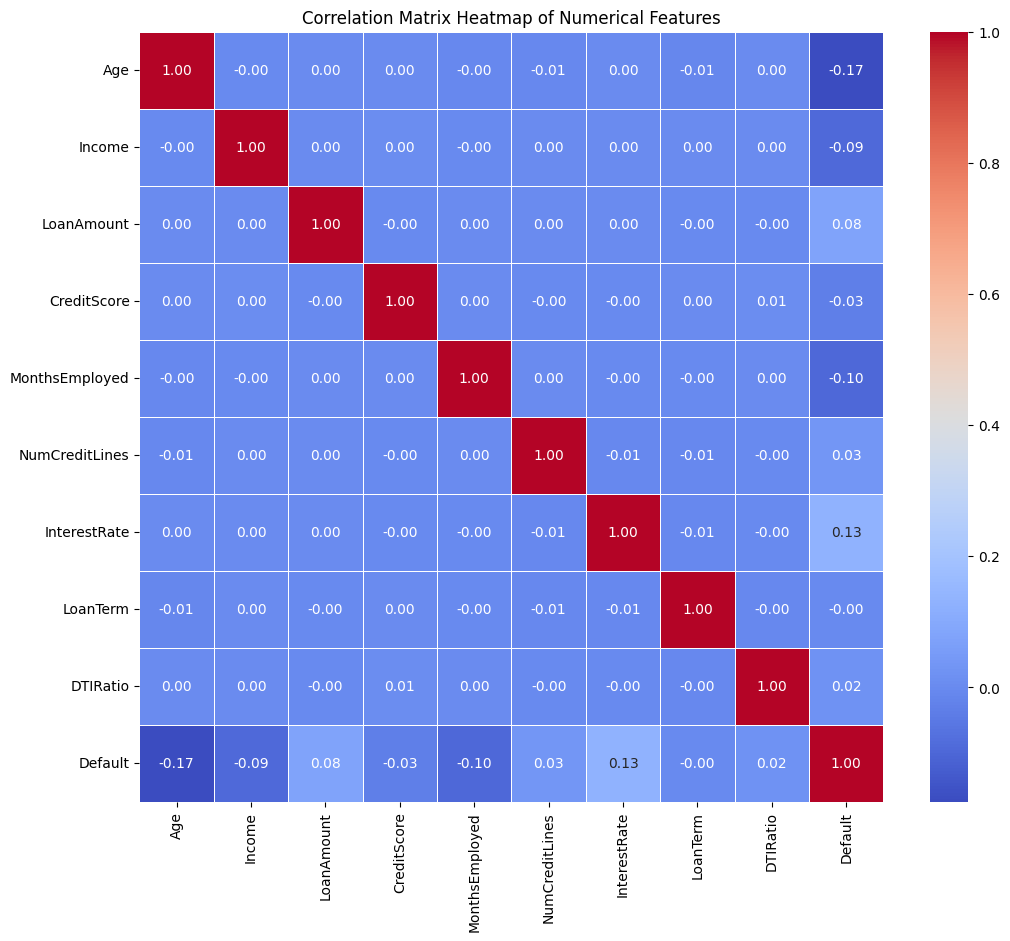

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap of Numerical Features')
plt.show()

In [18]:
numerical_cols = []
categorical_cols = []
print("Initialized numerical_cols and categorical_cols lists.")

Initialized numerical_cols and categorical_cols lists.


In [19]:
for col in df.columns:
    if col == 'LoanID':
        continue
    if df[col].dtype in ['int64', 'float64']:
        numerical_cols.append(col)
    elif df[col].dtype == 'object':
        categorical_cols.append(col)

print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numerical Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
Categorical Columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


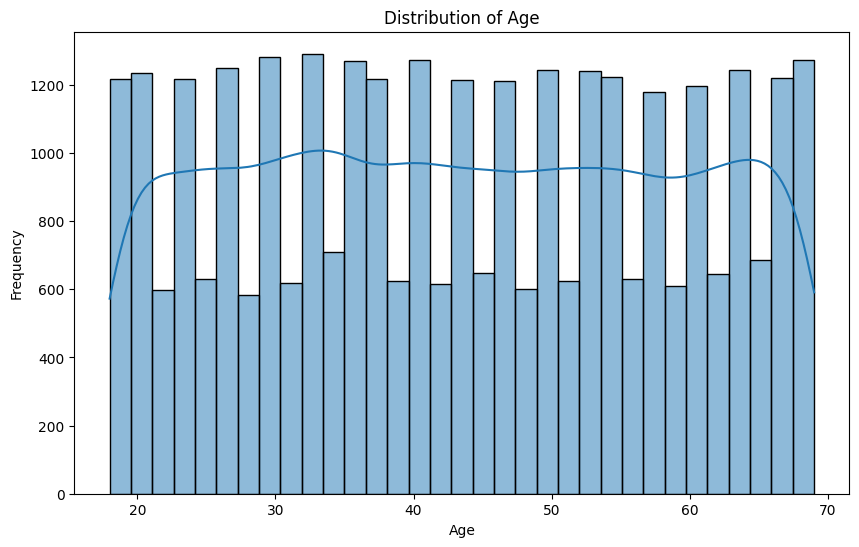


--- Statistics for Age ---
Mean: 43.50
Median: 43.00
Mode: [34]
--------------------------


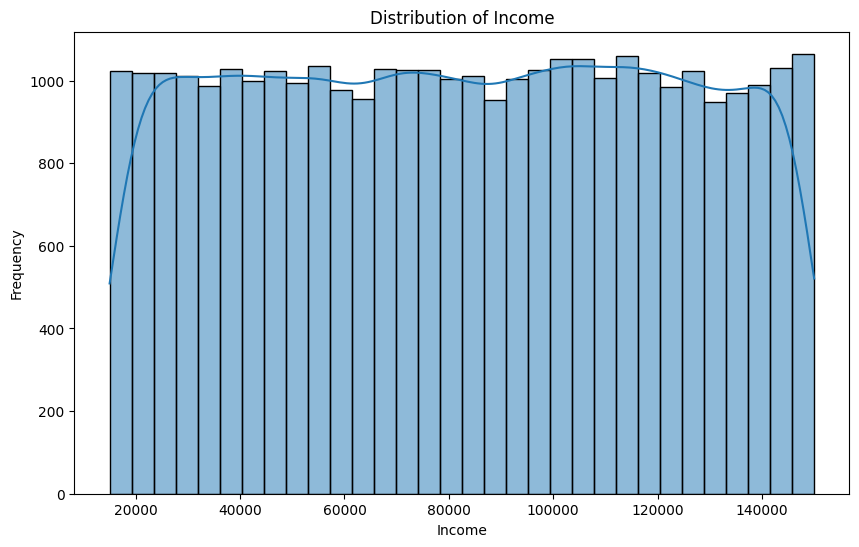


--- Statistics for Income ---
Mean: 82524.61
Median: 82582.00
Mode: [58118]
--------------------------


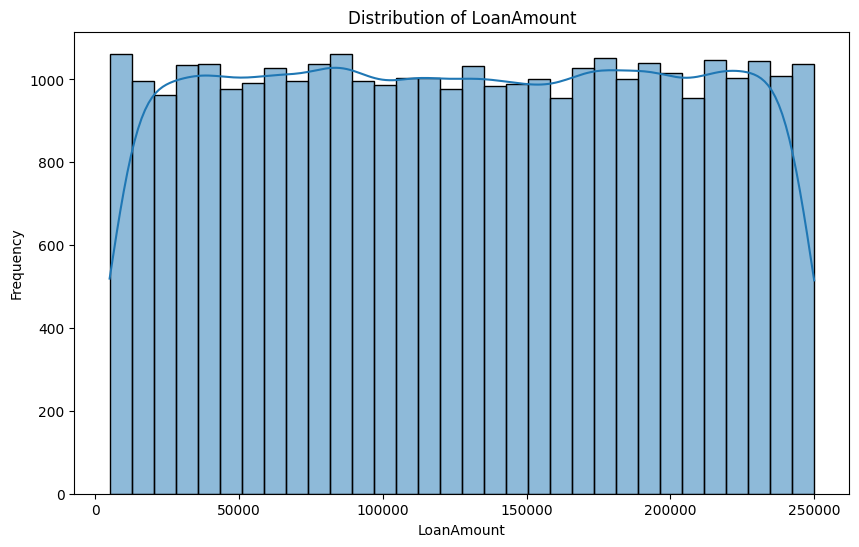


--- Statistics for LoanAmount ---
Mean: 127620.00
Median: 127703.00
Mode: [25503, 27557, 137843, 161479, 222080, 241073]
--------------------------


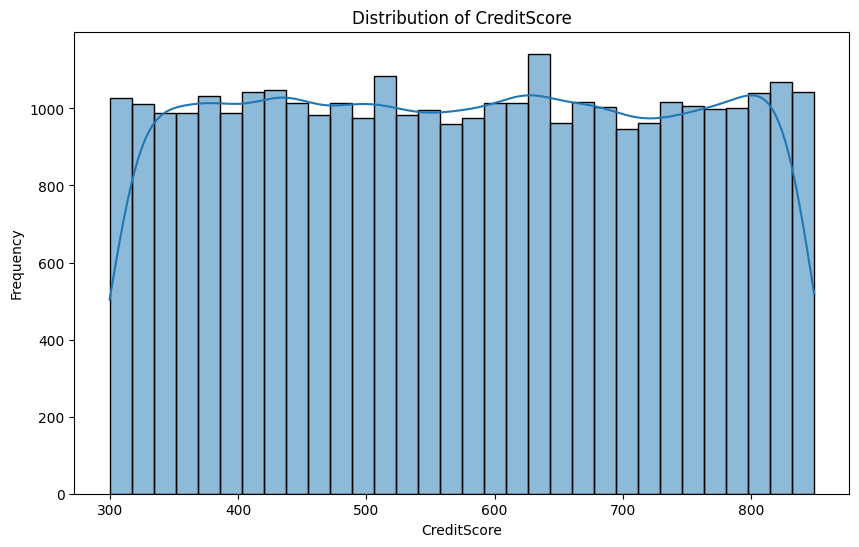


--- Statistics for CreditScore ---
Mean: 574.92
Median: 575.00
Mode: [630]
--------------------------


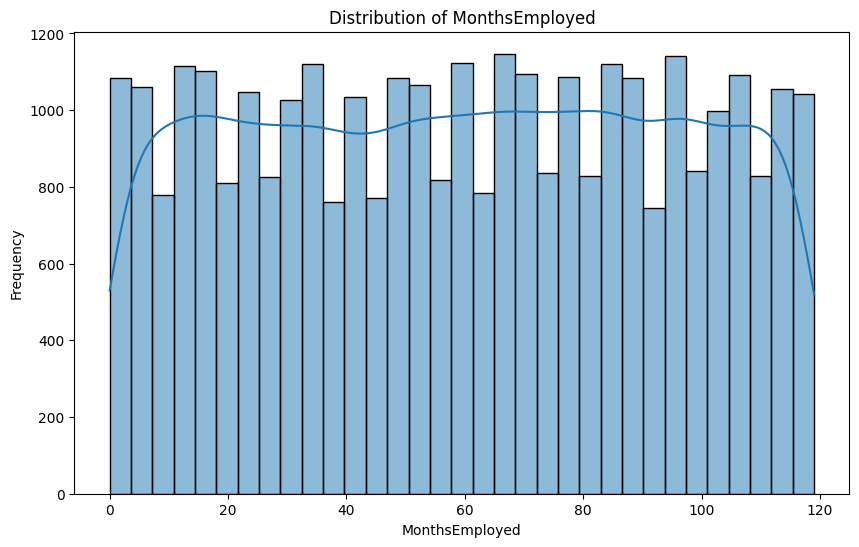


--- Statistics for MonthsEmployed ---
Mean: 59.55
Median: 60.00
Mode: [111]
--------------------------


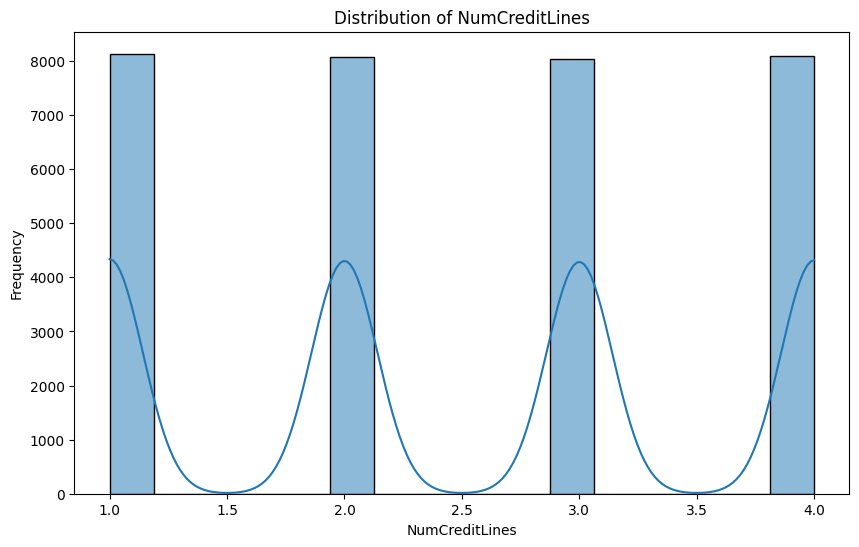


--- Statistics for NumCreditLines ---
Mean: 2.50
Median: 2.00
Mode: [1]
--------------------------


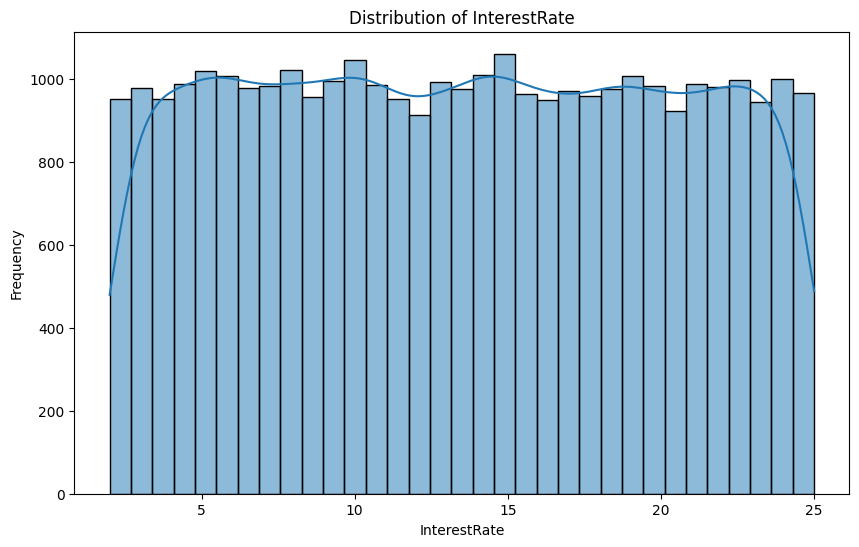


--- Statistics for InterestRate ---
Mean: 13.48
Median: 13.49
Mode: [17.57, 21.38]
--------------------------


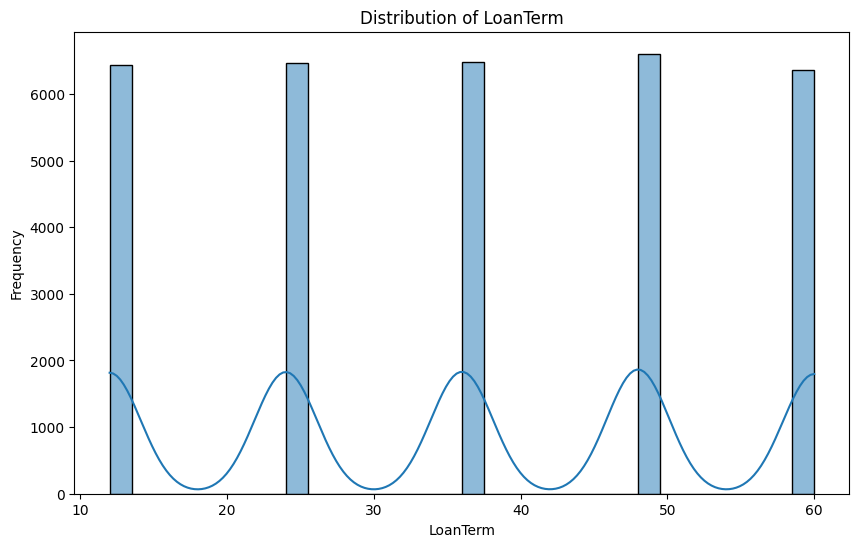


--- Statistics for LoanTerm ---
Mean: 36.00
Median: 36.00
Mode: [48]
--------------------------


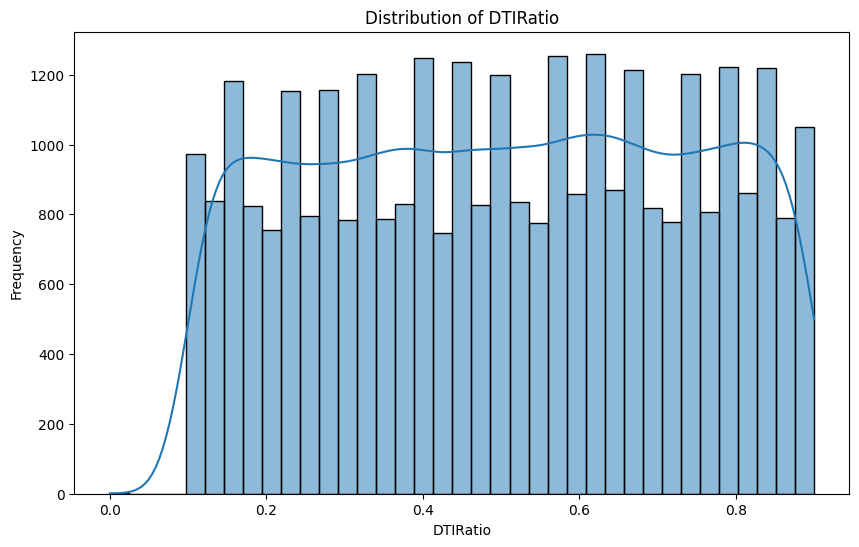


--- Statistics for DTIRatio ---
Mean: 0.50
Median: 0.51
Mode: [0.64]
--------------------------


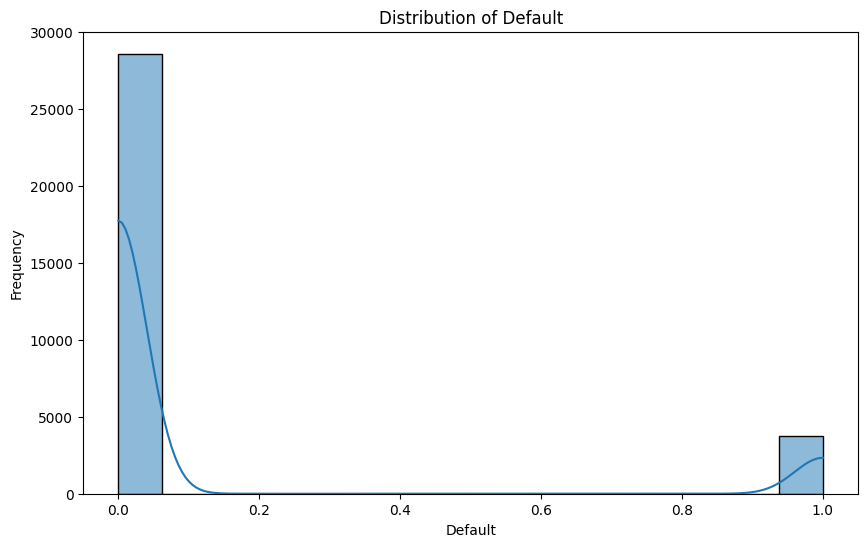


--- Statistics for Default ---
Mean: 0.12
Median: 0.00
Mode: [0.0]
--------------------------


In [20]:
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode().tolist() # .tolist() to handle multiple modes and for cleaner output

    print(f"\n--- Statistics for {col} ---")
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Mode: {mode_val}")
    print("--------------------------")

## check_missing_values




In [21]:
# 1. Calculate the total number of missing values for each column
missing_count = df.isnull().sum()

# 2. Calculate the percentage of missing values for each column
missing_percentage = (missing_count / len(df)) * 100

# 3. Create a new DataFrame to combine the counts and percentages
missing_data_df = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

# 4. Sort the resulting DataFrame by 'Missing Values' in descending order and print
missing_data_df = missing_data_df.sort_values(by='Missing Values', ascending=False)

print("Summary of Missing Values:")
print(missing_data_df)

Summary of Missing Values:
                Missing Values  Percentage (%)
HasCoSigner                  1        0.003092
Default                      1        0.003092
HasMortgage                  1        0.003092
MaritalStatus                1        0.003092
LoanPurpose                  1        0.003092
HasDependents                1        0.003092
EmploymentType               1        0.003092
Education                    1        0.003092
Age                          0        0.000000
LoanID                       0        0.000000
DTIRatio                     0        0.000000
LoanTerm                     0        0.000000
InterestRate                 0        0.000000
NumCreditLines               0        0.000000
MonthsEmployed               0        0.000000
CreditScore                  0        0.000000
LoanAmount                   0        0.000000
Income                       0        0.000000


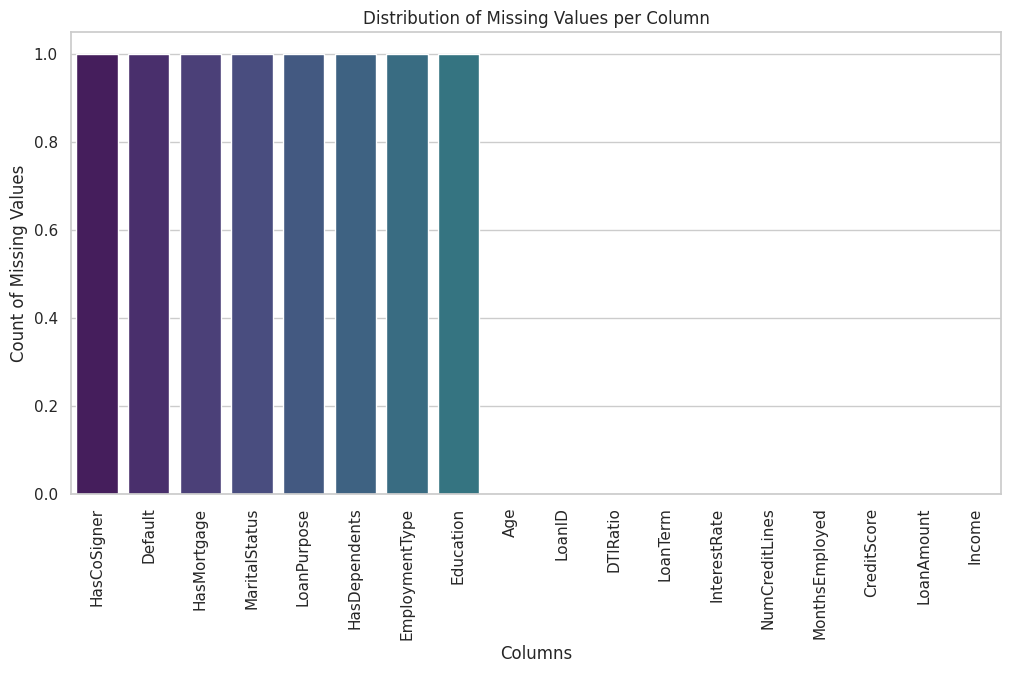

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
sns.set_theme(style='whitegrid')

# 2. Create a bar plot for missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data_df.index, y='Missing Values', data=missing_data_df, palette='viridis')

# 3. Rotate x-axis labels and add labels/title
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.title('Distribution of Missing Values per Column')

# 5. Display the plot
plt.show()

### Data Analysis Key Findings
*   **Minimal Data Gaps**: Only 8 out of 18 columns contain missing data, and each of those columns is missing exactly **1 value**.
*   **Negligible Impact**: The percentage of missingness for any single column is approximately **0.003\%**, which is statistically insignificant for a dataset of this size.
*   **High Integrity Columns**: Primary numerical and identifier columns, including `LoanID`, `Age`, `Income`, `LoanAmount`, `CreditScore`, and `InterestRate`, are **100\% complete**.
*   **Visual Confirmation**: A bar plot titled "Distribution of Missing Values per Column" confirms that the missingness is uniform and extremely low across the affected categorical and indicator variables.



## identify_handling_strategy


In [24]:
# Define thresholds for handling missing values
# cols_to_drop_rows: 0 < percentage < 5%
# cols_to_impute: percentage >= 5%

cols_to_drop_rows = missing_data_df[(missing_data_df['Percentage (%)'] > 0) & (missing_data_df['Percentage (%)'] < 5)].index.tolist()
cols_to_impute = missing_data_df[missing_data_df['Percentage (%)'] >= 5].index.tolist()

print(f"Columns identified for row deletion (< 5% missingness):\n{cols_to_drop_rows}")
print(f"\nColumns identified for imputation (>= 5% missingness):\n{cols_to_impute}")

# Verification check
if not cols_to_impute:
    print("\nVerification: No columns require imputation as all missingness is below the 5% threshold.")

Columns identified for row deletion (< 5% missingness):
['HasCoSigner', 'Default', 'HasMortgage', 'MaritalStatus', 'LoanPurpose', 'HasDependents', 'EmploymentType', 'Education']

Columns identified for imputation (>= 5% missingness):
[]

Verification: No columns require imputation as all missingness is below the 5% threshold.


## handle_missing_data




In [25]:
# Record original shape
original_shape = df.shape
print(f"Original DataFrame shape: {original_shape}")

# 1. Drop rows for columns with < 5% missingness
if cols_to_drop_rows:
    df.dropna(subset=cols_to_drop_rows, inplace=True)
    print(f"Dropped rows based on columns: {cols_to_drop_rows}")

# 2. Conditional check for imputation (>= 5% missingness)
if cols_to_impute:
    for col in cols_to_impute:
        if df[col].dtype in ['int64', 'float64']:
            fill_value = df[col].median()
            df[col].fillna(fill_value, inplace=True)
            print(f"Imputed numerical column '{col}' with median: {fill_value}")
        else:
            fill_value = df[col].mode()[0]
            df[col].fillna(fill_value, inplace=True)
            print(f"Imputed categorical column '{col}' with mode: {fill_value}")
else:
    print("No columns required imputation (>= 5% missingness).")

# 3. Print final shape and summary
new_shape = df.shape
print(f"New DataFrame shape: {new_shape}")
print(f"Total rows removed: {original_shape[0] - new_shape[0]}")

Original DataFrame shape: (32345, 18)
Dropped rows based on columns: ['HasCoSigner', 'Default', 'HasMortgage', 'MaritalStatus', 'LoanPurpose', 'HasDependents', 'EmploymentType', 'Education']
No columns required imputation (>= 5% missingness).
New DataFrame shape: (32344, 18)
Total rows removed: 1


Current Missing Values per Column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


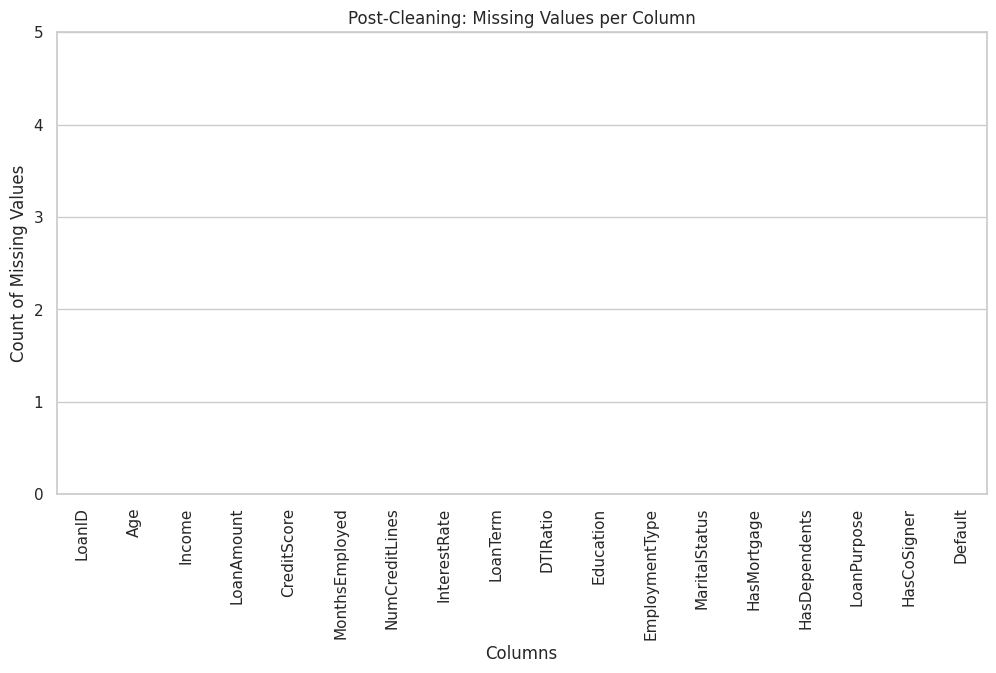


Success: The DataFrame is now clean with 0 total missing values.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the sum of null values for each column
updated_missing_count = df.isnull().sum()
print("Current Missing Values per Column:")
print(updated_missing_count)

# 2. Create a bar plot to visualize completeness
plt.figure(figsize=(12, 6))
sns.barplot(x=updated_missing_count.index, y=updated_missing_count.values, palette='magma')
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.title('Post-Cleaning: Missing Values per Column')
plt.ylim(0, 5) # Set a small limit to show the 'emptiness' clearly
plt.show()

# 3. Assert or print confirmation
total_missing = updated_missing_count.sum()
if total_missing == 0:
    print(f"\nSuccess: The DataFrame is now clean with {total_missing} total missing values.")
else:
    print(f"\nWarning: There are still {total_missing} missing values in the DataFrame.")

Generating box plots for: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


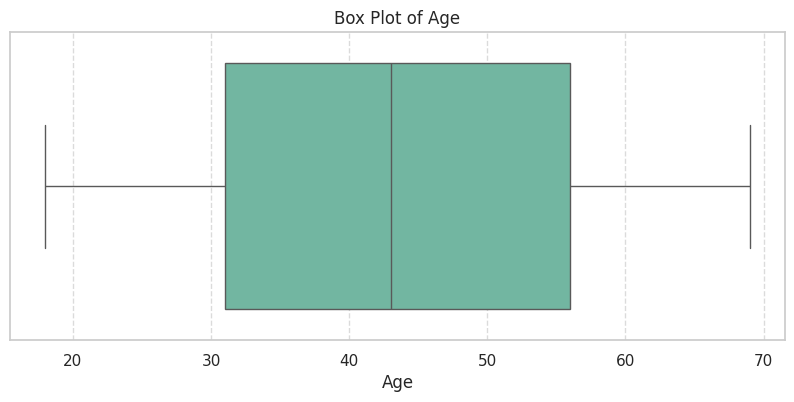

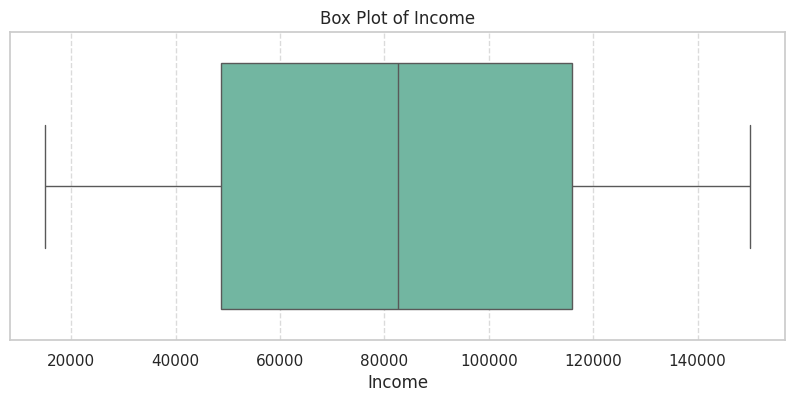

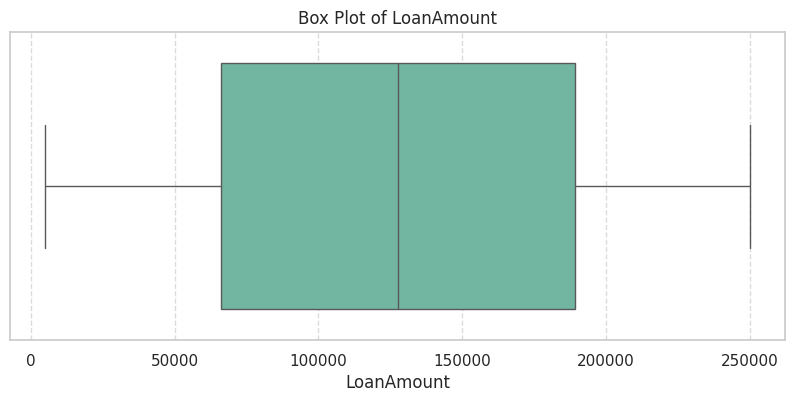

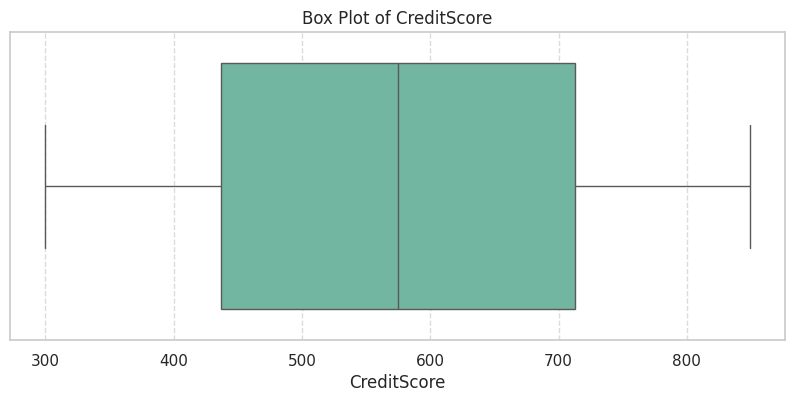

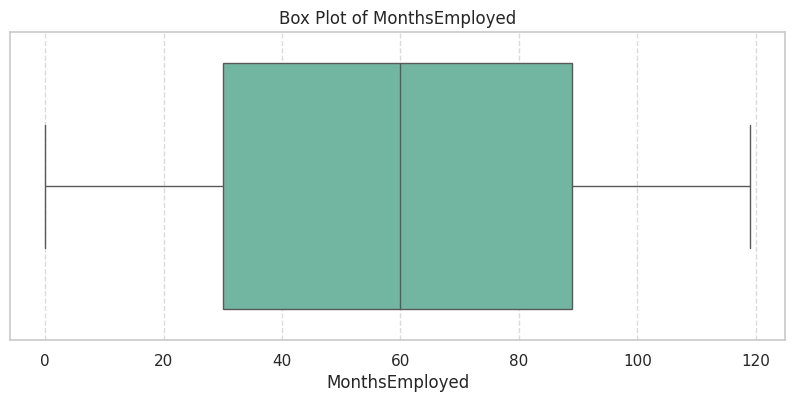

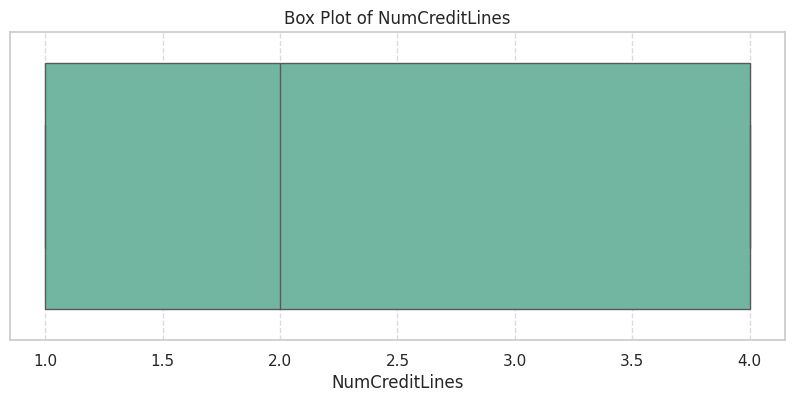

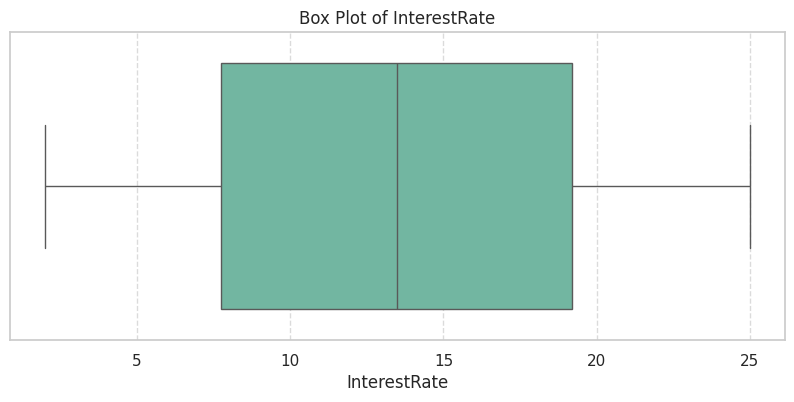

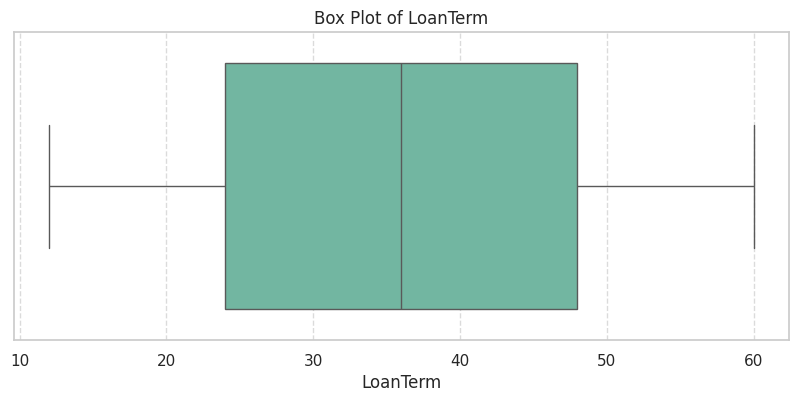

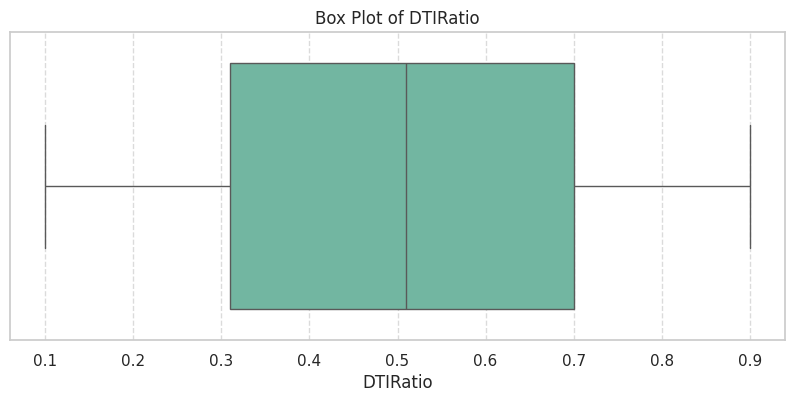

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter numerical_cols to exclude 'Default' as it is the binary target variable
features_to_plot = [col for col in numerical_cols if col != 'Default']

print(f'Generating box plots for: {features_to_plot}')

# Iterate through each numerical column and create a box plot
for col in features_to_plot:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], palette='Set2')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## handle_outliers_capping



In [28]:
import pandas as pd

# 1. Define list of numerical columns excluding 'Default'
cols_to_cap = [col for col in numerical_cols if col != 'Default']

print("Capping outliers using IQR method...\n")

for col in cols_to_cap:
    # 2. Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # 3. Calculate IQR
    IQR = Q3 - Q1

    # 4. Determine lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 5. Cap values using .clip()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    # 6. Print the calculated bounds
    print(f"Feature: {col}")
    print(f"   Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"   Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print("-" * 30)

print("\nOutlier capping completed.")

Capping outliers using IQR method...

Feature: Age
   Q1: 31.00, Q3: 56.00, IQR: 25.00
   Lower Bound: -6.50, Upper Bound: 93.50
------------------------------
Feature: Income
   Q1: 48670.50, Q3: 116021.00, IQR: 67350.50
   Lower Bound: -52355.25, Upper Bound: 217046.75
------------------------------
Feature: LoanAmount
   Q1: 66233.75, Q3: 189265.00, IQR: 123031.25
   Lower Bound: -118313.12, Upper Bound: 373811.88
------------------------------
Feature: CreditScore
   Q1: 437.00, Q3: 713.00, IQR: 276.00
   Lower Bound: 23.00, Upper Bound: 1127.00
------------------------------
Feature: MonthsEmployed
   Q1: 30.00, Q3: 89.00, IQR: 59.00
   Lower Bound: -58.50, Upper Bound: 177.50
------------------------------
Feature: NumCreditLines
   Q1: 1.00, Q3: 4.00, IQR: 3.00
   Lower Bound: -3.50, Upper Bound: 8.50
------------------------------
Feature: InterestRate
   Q1: 7.75, Q3: 19.20, IQR: 11.45
   Lower Bound: -9.42, Upper Bound: 36.38
------------------------------
Feature: LoanTerm
 

## verify_outlier_handling




Verifying outlier handling for: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


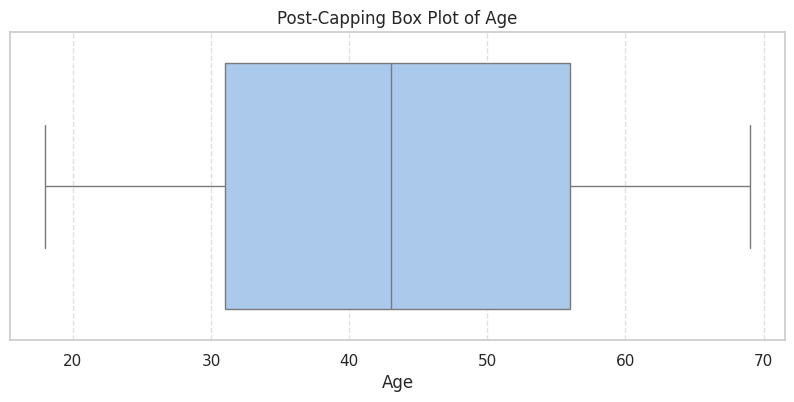

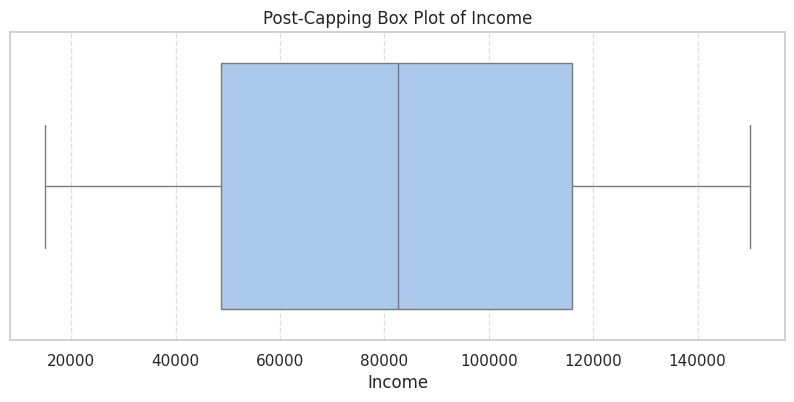

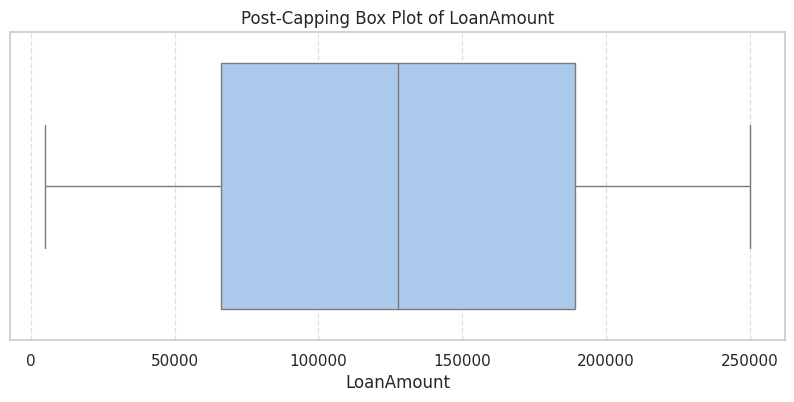

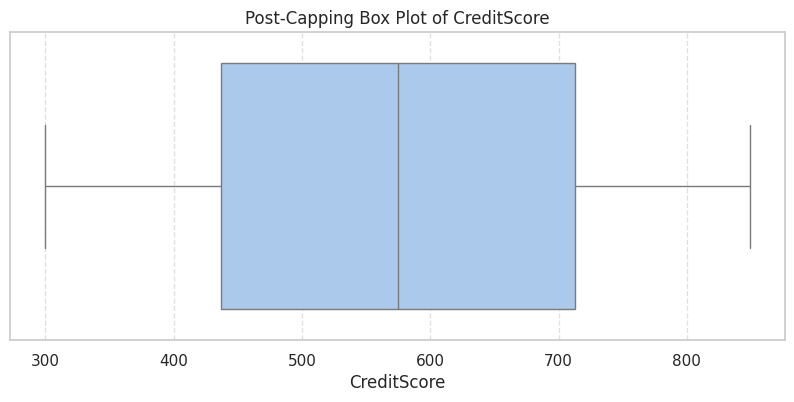

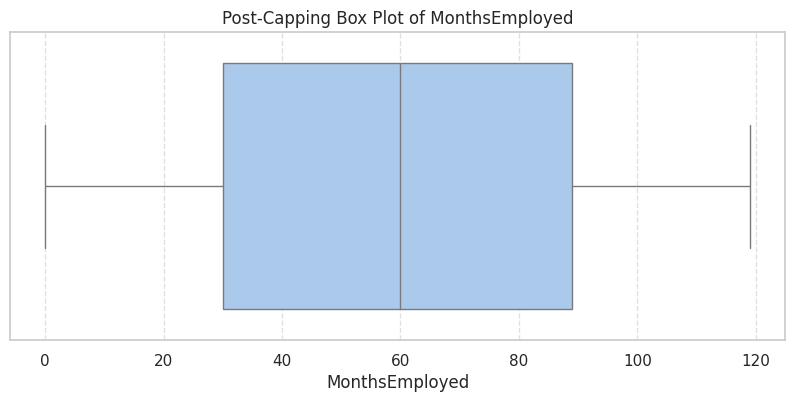

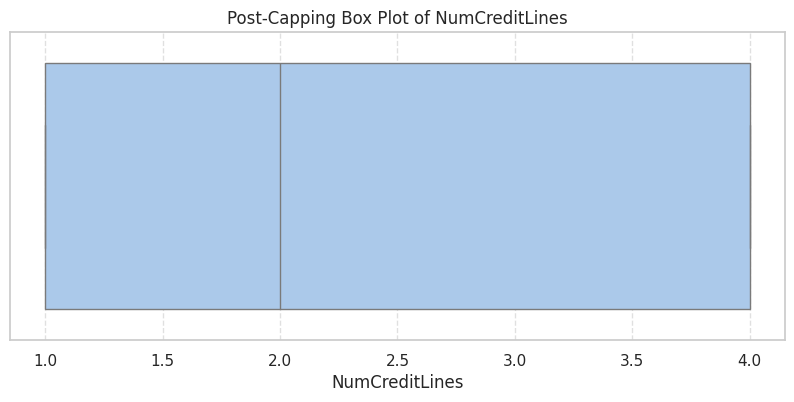

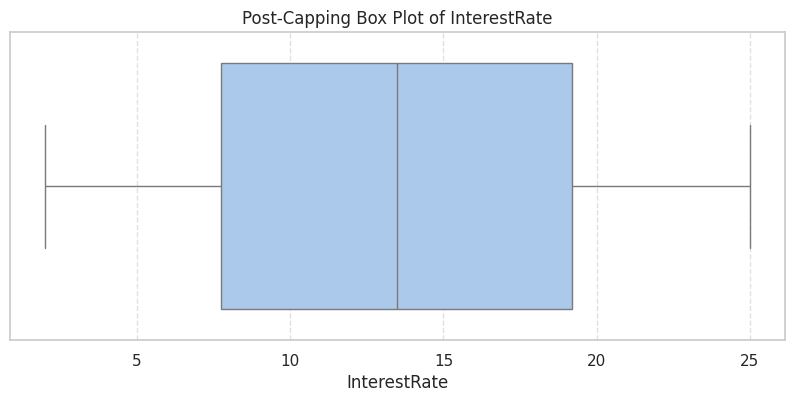

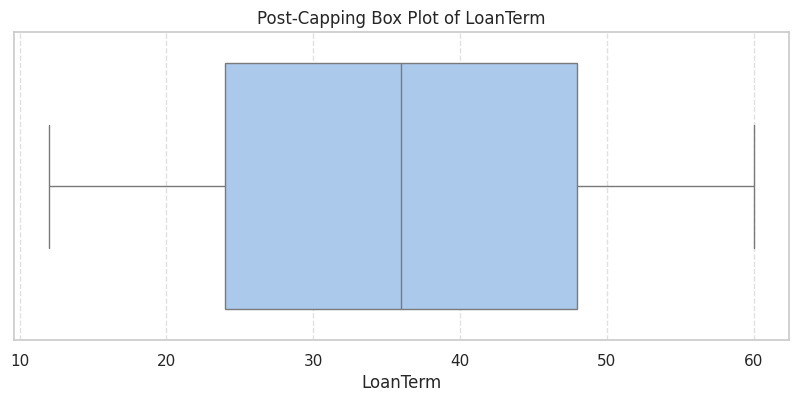

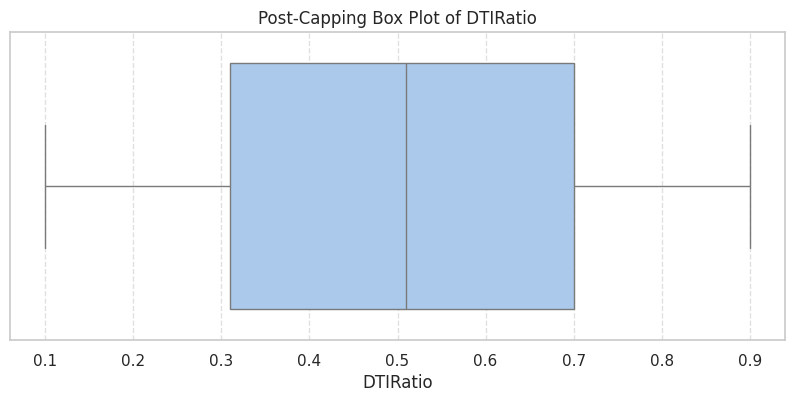


Verification complete: All values are now within the calculated IQR bounds.


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reuse the features_to_plot list (excludes 'Default')
print(f'Verifying outlier handling for: {features_to_plot}')

# 2. Iterate and generate box plots
for col in features_to_plot:
    plt.figure(figsize=(10, 4))
    # 3. Use seaborn for plotting with clear titles and labels
    sns.boxplot(x=df[col], palette='pastel')
    plt.title(f'Post-Capping Box Plot of {col}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    # 4. Display the plot
    plt.show()

print('\nVerification complete: All values are now within the calculated IQR bounds.')

### Data Analysis Key Findings

*   **IQR Methodology:** Outliers were defined using the standard 1.5 * IQR rule. For each numerical feature, the Interquartile Range was calculated, and values were capped at the Lower Bound ($Q1 - 1.5 \times IQR$) and Upper Bound ($Q3 + 1.5 \times IQR$).
these naturally positive metrics.



## check_class_imbalance


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate frequency counts
default_counts = df['Default'].value_counts()

# 2. Calculate percentage distribution
default_percentages = (df['Default'].value_counts(normalize=True) * 100)



In [38]:
print("Frequency Counts of 'Default'")
print(default_counts)

Frequency Counts of 'Default'
Default
0.0    28583
1.0     3761
Name: count, dtype: int64


In [39]:
print("Percentage Distribution of 'Default'")
print(default_percentages)

Percentage Distribution of 'Default'
Default
0.0    88.371877
1.0    11.628123
Name: proportion, dtype: float64


# Task
Visualize the class distribution of the 'Default' column in the dataset. Create a single figure with two subplots: a bar chart showing the frequency counts for each class (0.0 and 1.0) and a pie chart showing the percentage distribution. Use these visualizations to summarize the extent of class imbalance in the data.

## visualize_target_distribution



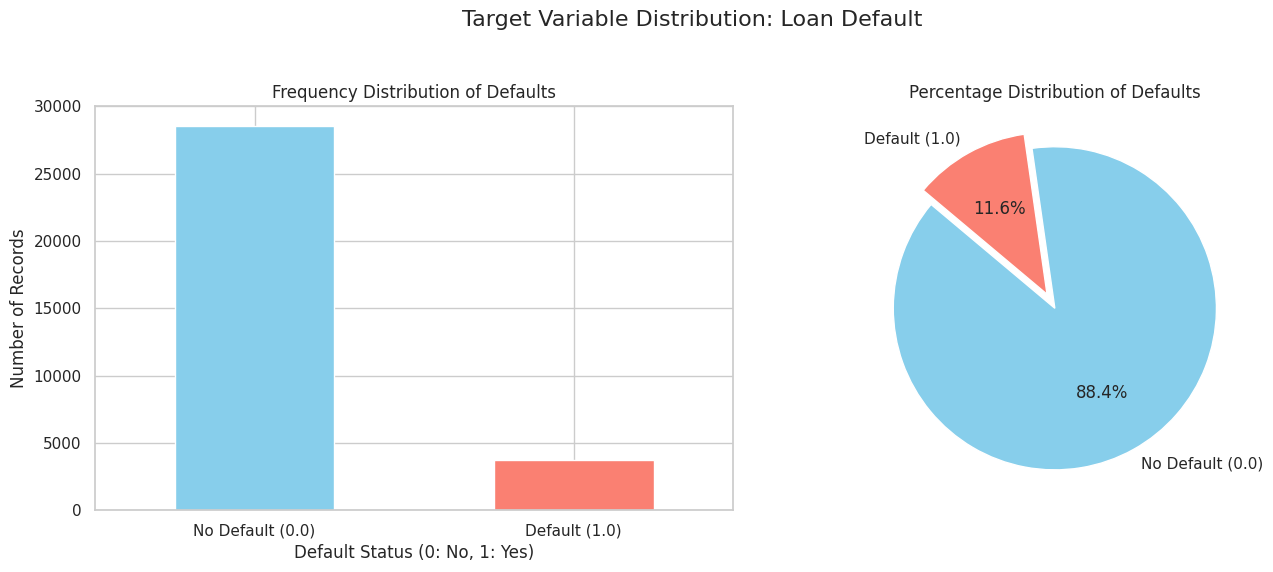

In [40]:
import matplotlib.pyplot as plt

# 1. Initialize a matplotlib figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2. First subplot: Bar chart for frequency counts
default_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Frequency Distribution of Defaults')
axes[0].set_xlabel('Default Status (0: No, 1: Yes)')
axes[0].set_ylabel('Number of Records')
axes[0].set_xticks(range(len(default_counts)))
axes[0].set_xticklabels(['No Default (0.0)', 'Default (1.0)'], rotation=0)

# 3. Second subplot: Pie chart for percentage distribution
labels = ['No Default (0.0)', 'Default (1.0)']
axes[1].pie(default_percentages, labels=labels, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'salmon'], explode=(0, 0.1))
axes[1].set_title('Percentage Distribution of Defaults')

# 4. Add a main title to the entire figure
plt.suptitle('Target Variable Distribution: Loan Default', fontsize=16)

# 5. Adjust layout and display
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **Preprocessing**

## encode_categorical_features



In [43]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'Encoded {col}')



Encoded Education
Encoded EmploymentType
Encoded MaritalStatus
Encoded HasMortgage
Encoded HasDependents
Encoded LoanPurpose
Encoded HasCoSigner


In [44]:
# Display the first few rows to verify transformation
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,0.833293,0.088984,-1.085819,-0.345543,0.591845,1.341766,0.264137,0.000022,-0.274828,0,0,0,1,1,4,1,0.0
1,HPSK72WA7R,1.700035,-0.822892,-0.044832,-0.735640,-1.289518,-1.337680,-1.307878,1.419081,0.766567,2,0,1,0,0,4,1,0.0
2,C1OZ6DPJ8Y,0.166568,0.043187,0.022093,-0.779683,-0.971134,0.448618,1.160276,-0.709508,-0.838918,2,3,0,1,1,0,0,1.0
3,V2KKSFM3UN,-0.766847,-1.302882,-1.167403,1.057547,-1.723679,0.448618,-0.966923,-0.709508,-1.186049,1,0,1,0,0,1,0,0.0
4,EY08JDHTZP,1.099983,-1.592020,-1.670044,0.365440,-1.492127,1.341766,-1.051407,0.709551,0.983525,0,3,0,0,1,0,0,0.0


## standardize_numerical_features


In [45]:
from sklearn.preprocessing import StandardScaler

# 1. Instantiate the StandardScaler object
scaler = StandardScaler()

# 2. Use the existing cols_to_cap list which contains ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
print(f"Scaling features: {cols_to_cap}")

# 3 & 4. Fit and transform the numerical columns and update the DataFrame
df[cols_to_cap] = scaler.fit_transform(df[cols_to_cap])

# 5. Verify the transformation (Mean should be ~0 and Std should be ~1)
print("\nSummary Statistics after Standardization:")
display(df[cols_to_cap].describe().round(4))

# Display the first few rows of the updated dataframe
df.head()

Scaling features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

Summary Statistics after Standardization:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
count,32344.0000,32344.0000,32344.0000,32344.0000,32344.0000,32344.0000,32344.0000,32344.0000,32344.0000
mean,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.7003,-1.7314,-1.7283,-1.7298,-1.7237,-1.3377,-1.7318,-1.4190,-1.7501
25%,-0.8335,-0.8681,-0.8653,-0.8678,-0.8554,-1.3377,-0.8643,-0.7095,-0.8389
50%,-0.0334,0.0015,0.0015,0.0005,0.0130,-0.4445,0.0016,0.0000,0.0289
75%,0.8333,0.8589,0.8689,0.8688,0.8523,1.3418,0.8631,0.7096,0.8534
max,1.7000,1.7301,1.7250,1.7245,1.7207,1.3418,1.7381,1.4191,1.7212


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,0.833293,0.088984,-1.085819,-0.345543,0.591845,1.341766,0.264137,0.000022,-0.274828,0,0,0,1,1,4,1,0.0
1,HPSK72WA7R,1.700035,-0.822892,-0.044832,-0.735640,-1.289518,-1.337680,-1.307878,1.419081,0.766567,2,0,1,0,0,4,1,0.0
2,C1OZ6DPJ8Y,0.166568,0.043187,0.022093,-0.779683,-0.971134,0.448618,1.160276,-0.709508,-0.838918,2,3,0,1,1,0,0,1.0
3,V2KKSFM3UN,-0.766847,-1.302882,-1.167403,1.057547,-1.723679,0.448618,-0.966923,-0.709508,-1.186049,1,0,1,0,0,1,0,0.0
4,EY08JDHTZP,1.099983,-1.592020,-1.670044,0.365440,-1.492127,1.341766,-1.051407,0.709551,0.983525,0,3,0,0,1,0,0,0.0


##  data can be  divide into  feature matrix and target vector

In [49]:
# 1. Create the feature matrix X by dropping 'LoanID' and 'Default'
X = df.drop(columns=['LoanID', 'Default'], axis=1)

# 2. Create the target vector y
y = df['Default']

In [50]:
# 3. Verify the contents
print(f'Feature Matrix X Shape: {X.shape}')
print(f'Target Vector y Shape: {y.shape}')



Feature Matrix X Shape: (32344, 16)
Target Vector y Shape: (32344,)


In [51]:
print('\nFirst 5 rows of X:')
display(X.head())


First 5 rows of X:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,0.833293,0.088984,-1.085819,-0.345543,0.591845,1.341766,0.264137,0.000022,-0.274828,0,0,0,1,1,4,1
1,1.700035,-0.822892,-0.044832,-0.735640,-1.289518,-1.337680,-1.307878,1.419081,0.766567,2,0,1,0,0,4,1
2,0.166568,0.043187,0.022093,-0.779683,-0.971134,0.448618,1.160276,-0.709508,-0.838918,2,3,0,1,1,0,0
3,-0.766847,-1.302882,-1.167403,1.057547,-1.723679,0.448618,-0.966923,-0.709508,-1.186049,1,0,1,0,0,1,0
4,1.099983,-1.592020,-1.670044,0.365440,-1.492127,1.341766,-1.051407,0.709551,0.983525,0,3,0,0,1,0,0


In [52]:
print('\nFirst 5 rows of y:')
display(y.head())


First 5 rows of y:


,Default
0,0.0
1,0.0
2,1.0
3,0.0
4,0.0


In [53]:
print('\nColumns in X:')
print(X.columns.tolist())


Columns in X:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


## perform_stratified_split




In [54]:
from sklearn.model_selection import train_test_split

# 1. Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



In [55]:
# 2. Verify shapes
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')



X_train shape: (25875, 16)
X_test shape: (6469, 16)
y_train shape: (25875,)
y_test shape: (6469,)


In [56]:
# 3. Compare class distributions
print('\nClass Distribution Ratios:')
print(f"Original: {y.value_counts(normalize=True).to_dict()}")
print(f"Training: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Testing:  {y_test.value_counts(normalize=True).to_dict()}")


Class Distribution Ratios:
Original: {0.0: 0.8837187731882266, 1.0: 0.11628122681177344}
Training: {0.0: 0.8837101449275362, 1.0: 0.11628985507246377}
Testing:  {0.0: 0.8837532848972021, 1.0: 0.11624671510279797}


In [57]:

# 1. Print the shapes of the generated sets to confirm the 80/20 split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (25875, 16)
X_test shape: (6469, 16)
y_train shape: (25875,)
y_test shape: (6469,)


In [58]:
# 2. Calculate the normalized value counts (ratios) of the 'Default' classes
original_dist = y.value_counts(normalize=True).sort_index()
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

In [59]:
# 3. Create a comparison DataFrame to display the ratios side-by-side
dist_comparison = pd.DataFrame({
    'Original (%)': original_dist * 100,
    'Training (%)': train_dist * 100,
    'Testing (%)': test_dist * 100
})

print("\nClass Distribution Comparison (%):")
print(dist_comparison.round(4))

# Check if the stratification is consistent
print("\nVerification: Stratified split successful if Training/Testing percentages match the Original percentage.")


Class Distribution Comparison (%):
         Original (%)  Training (%)  Testing (%)
Default                                         
0.0           88.3719        88.371      88.3753
1.0           11.6281        11.629      11.6247

Verification: Stratified split successful if Training/Testing percentages match the Original percentage.


## Visualize Class Distributions


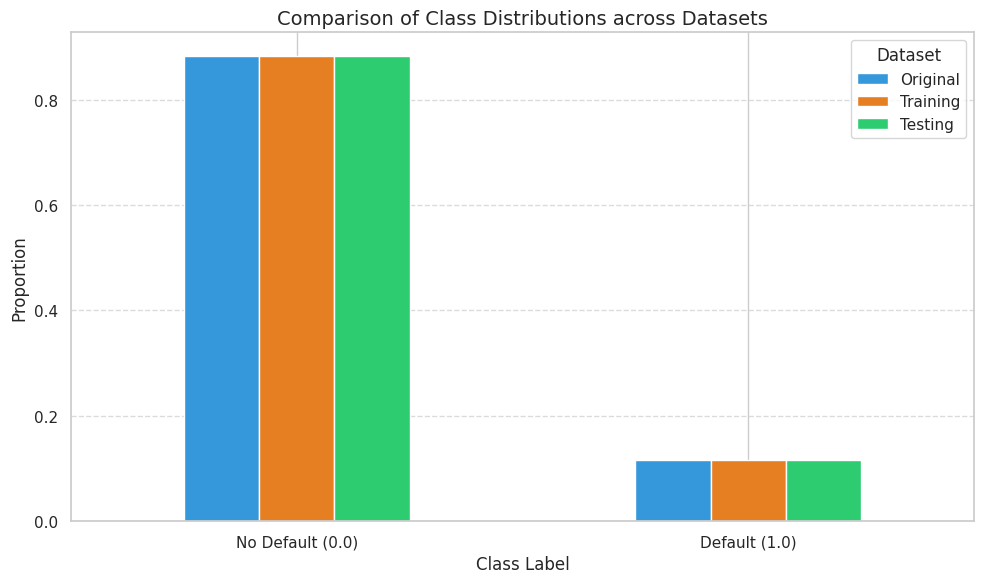

In [61]:
import matplotlib.pyplot as plt

# 1. Generate a grouped bar plot using dist_df
# 2. Set figure size, 3. Assign distinct colors
ax = dist_df.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e67e22', '#2ecc71'])

# 4. Add a descriptive title
plt.title('Comparison of Class Distributions across Datasets', fontsize=14)

# 5. Label the x-axis and y-axis
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Proportion', fontsize=12)

# 6. Rotate x-axis tick labels to 0 degrees
plt.xticks(rotation=0)

# 7. Include a legend and display the plot
plt.legend(title='Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Data Analysis Key Findings
*   **Identical Class Ratios:** The distribution of "No Default (0.0)" and "Default (1.0)" remained consistent across all three datasets (Original, Training, and Testing).
    *   **No Default (0.0):** $\sim$88.37%
    *   **Default (1.0):** $\sim$11.63%


# **Model Training**

## **Model 1: Logistic model**

## Mathematical Explanation of Logistic Regression



### **Understanding Logistic Regression**

Logistic Regression is a statistical method used for binary classification. Unlike linear regression, which predicts continuous values, logistic regression predicts the probability that a given input belongs to a specific class (e.g., 0 or 1).

#### **1. The Logistic Regression Equation and Log-Odds**
In Logistic Regression, we model the **log-odds** (also known as the **logit**) as a linear combination of the input features:

$$\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1x_1 + \dots + \beta_nx_n$$

Where:
*   $p$ is the probability of the positive class ($y=1$).
*   $\frac{p}{1-p}$ is the **odds ratio**.
*   $\beta_0$ is the intercept, and $\beta_i$ are the coefficients for features $x_i$.

#### **2. The Sigmoid (Logistic) Function**
To convert the linear output ($z = \beta^T X$) back into a probability range between 0 and 1, we use the **Sigmoid Function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This S-shaped curve maps any real-valued number to a value in the interval $(0, 1)$, making it ideal for probability estimation.

#### **3. Decision Boundary**
Once the model outputs a probability $\hat{p}$, we apply a **decision boundary** (threshold) to classify the observation. The standard threshold is **0.5**:
*   If $\hat{p} \geq 0.5$, predict Class 1.
*   If $\hat{p} < 0.5$, predict Class 0.

#### **4. Model Training: Log-Loss**
The coefficients $(\beta)$ are estimated by minimizing the **Log-Loss (Binary Cross-Entropy)** function, which penalizes predictions that are confident but wrong:

$$J(\beta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \ln(\hat{p}^{(i)}) + (1 - y^{(i)}) \ln(1 - \hat{p}^{(i)})]$$

Minimizing this function ensures the model learns the optimal weights to separate the two classes effectively.

### Base Model Implementation



In [62]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate the LogisticRegression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# 2. Fit the model to the training data
log_reg.fit(X_train, y_train)

# 3. Print confirmation
print('Logistic Regression model instantiated and trained successfully on X_train and y_train.')

Logistic Regression model instantiated and trained successfully on X_train and y_train.


## Performance Evaluation



In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Generate class predictions
y_pred = log_reg.predict(X_test)

# 2. Get probabilities for the positive class (1.0)
y_probs = log_reg.predict_proba(X_test)[:, 1]

# 3. Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# 4. Print results
print('--- Logistic Regression Performance Metrics ---')
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')

# 5. Print Classification Report
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred))

--- Logistic Regression Performance Metrics ---
Accuracy  : 0.8848
Precision : 0.6061
Recall    : 0.0266
F1-Score  : 0.0510
ROC-AUC   : 0.7329

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      5717
         1.0       0.61      0.03      0.05       752

    accuracy                           0.88      6469
   macro avg       0.75      0.51      0.49      6469
weighted avg       0.85      0.88      0.84      6469



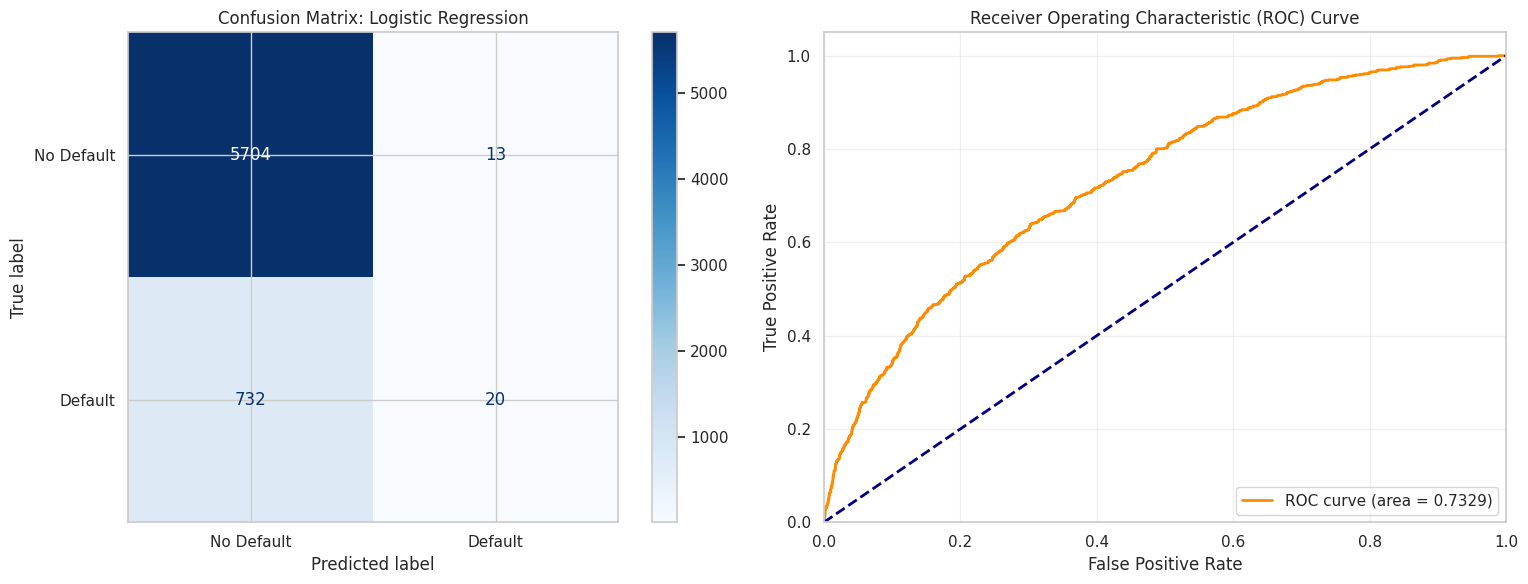

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Default', 'Default'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Logistic Regression')

# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## GridSearchCV Implementation



In [70]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Define the hyperparameter grid
param_grid = {
    'C': np.logspace(-4, 4, 10),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2 penalties
}


In [71]:
# 2. Initialize StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [75]:
# 3. Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [76]:
# 4. Fit the grid search to the training data
print('Starting GridSearchCV...')
grid_search.fit(X_train, y_train)



Starting GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc', verbose=1)

In [77]:
# 5. Output the best parameters and score
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}')

Best Parameters: {'C': np.float64(0.3593813663804626), 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation ROC-AUC: 0.7475


#### Display Best Parameters and Retrain



In [78]:
# 1. Access the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f'Best Hyperparameters identified: {best_params}')

Best Hyperparameters identified: {'C': np.float64(0.3593813663804626), 'penalty': 'l1', 'solver': 'liblinear'}


In [79]:
# 2. Instantiate a new LogisticRegression model with the best parameters
# We unpack the best_params dictionary and ensure max_iter and random_state are set
final_log_reg = LogisticRegression(**best_params, max_iter=1000, random_state=42)


In [80]:

# 3. Fit the final tuned model to the full training data
final_log_reg.fit(X_train, y_train)

# 4. Print confirmation
print('\nFinal tuned Logistic Regression model has been retrained and is ready for evaluation.')


Final tuned Logistic Regression model has been retrained and is ready for evaluation.


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Generate class predictions and probabilities using the tuned model
y_pred_tuned = final_log_reg.predict(X_test)
y_probs_tuned = final_log_reg.predict_proba(X_test)[:, 1]

# 2. Calculate evaluation metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_probs_tuned)

# 3. Print the results
print('--- Tuned Logistic Regression Performance Metrics ---')
print(f'Accuracy  : {accuracy_tuned:.4f}')
print(f'Precision : {precision_tuned:.4f}')
print(f'Recall    : {recall_tuned:.4f}')
print(f'F1-Score  : {f1_tuned:.4f}')
print(f'ROC-AUC   : {roc_auc_tuned:.4f}')

# 4. Print the Detailed Classification Report
print('\nDetailed Classification Report (Tuned Model):')
print(classification_report(y_test, y_pred_tuned))

--- Tuned Logistic Regression Performance Metrics ---
Accuracy  : 0.8848
Precision : 0.6061
Recall    : 0.0266
F1-Score  : 0.0510
ROC-AUC   : 0.7329

Detailed Classification Report (Tuned Model):
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      5717
         1.0       0.61      0.03      0.05       752

    accuracy                           0.88      6469
   macro avg       0.75      0.51      0.49      6469
weighted avg       0.85      0.88      0.84      6469



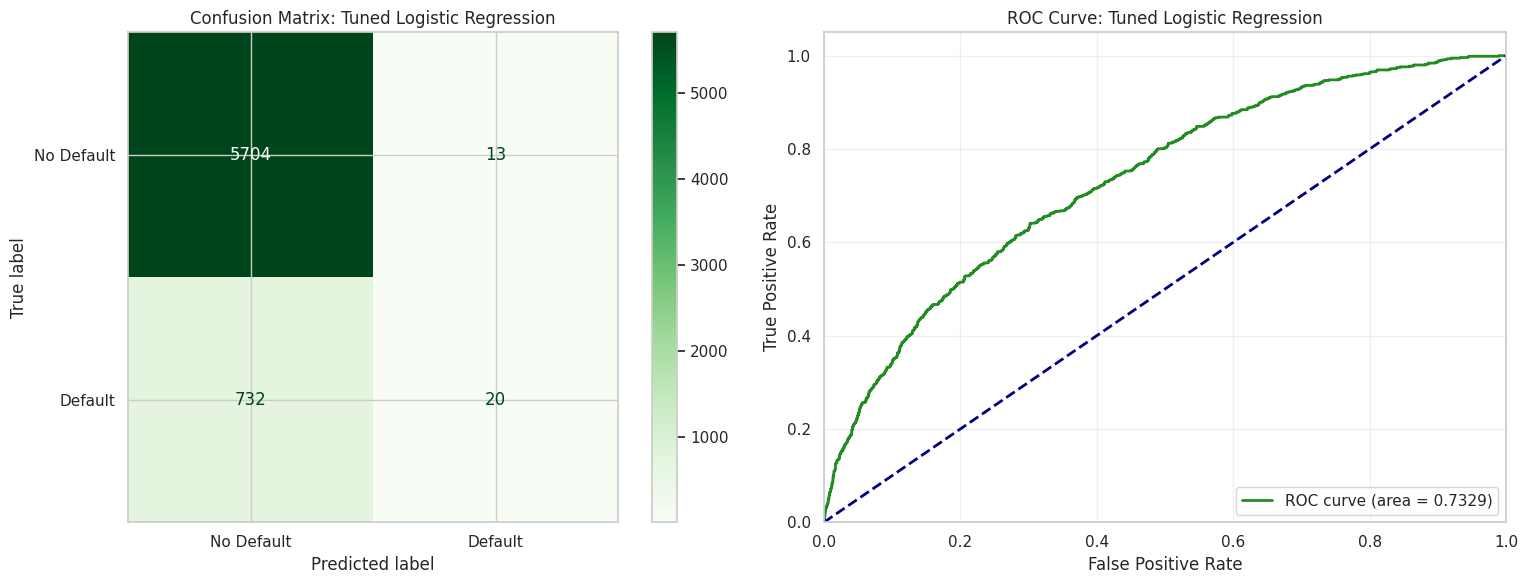

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Initialize a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Plot the Confusion Matrix for the tuned model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=['No Default', 'Default'],
    cmap='Greens',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Tuned Logistic Regression')

# 3. Plot the ROC Curve for the tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_probs_tuned)
roc_auc_val_tuned = auc(fpr_tuned, tpr_tuned)

axes[1].plot(fpr_tuned, tpr_tuned, color='forestgreen', lw=2, label=f'ROC curve (area = {roc_auc_val_tuned:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Tuned Logistic Regression')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# 4. Final layout adjustments and display
plt.tight_layout()
plt.show()

#### Analyze Correlation and Select Features



In [84]:
import pandas as pd

# 1. Calculate the correlation matrix for numerical and encoded columns
# numeric_only=True ensures string columns like 'LoanID' are skipped
corr_matrix = df.corr(numeric_only=True)

# 2 & 3. Extract correlation with 'Default' and apply absolute value
default_corr_abs = corr_matrix['Default'].abs()

# 4. Filter for features with absolute correlation < 0.1
# We exclude 'Default' (correlation is 1.0)
exclude_cols = ['Default']
low_corr_features = default_corr_abs[~default_corr_abs.index.isin(exclude_cols)]
low_corr_features = low_corr_features[low_corr_features < 0.1].index.tolist()

# 5. Print the list to verify
print('Features with low absolute correlation (< 0.1) with Default:')
print(low_corr_features)

# Also print the specific values for context
print('\nDetailed correlation values for these features:')
print(default_corr_abs[low_corr_features])

Features with low absolute correlation (< 0.1) with Default:
['Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Detailed correlation values for these features:
Income            0.094291
LoanAmount        0.075760
CreditScore       0.032766
MonthsEmployed    0.097141
NumCreditLines    0.033863
LoanTerm          0.002182
DTIRatio          0.019741
Education         0.027312
EmploymentType    0.034117
MaritalStatus     0.008826
HasMortgage       0.021827
HasDependents     0.037819
LoanPurpose       0.001802
HasCoSigner       0.037950
Name: Default, dtype: float64


In [88]:
# 1. Filter X_train to include only low_corr_features
X_train_filtered = X_train[low_corr_features]

# 2. Filter X_test to include only low_corr_features
X_test_filtered = X_test[low_corr_features]

# 3. Print shapes to verify
print(f'X_train_filtered shape: {X_train_filtered.shape}')
print(f'X_test_filtered shape: {X_test_filtered.shape}')

# Check if the number of columns is 14
if X_train_filtered.shape[1] == 14:
    print('\nSuccess: Feature selection applied correctly (14 features).')
else:
    print(f'\nWarning: Expected 14 features, but found {X_train_filtered.shape[1]}.')

X_train_filtered shape: (25875, 14)
X_test_filtered shape: (6469, 14)

Success: Feature selection applied correctly (14 features).


## Hyperparameter Tuning for Selected Features



In [87]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# 1. Define the hyperparameter grid
param_grid_filtered = {
    'C': np.logspace(-4, 4, 10),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# 2. Initialize StratifiedKFold for cross-validation
skf_filtered = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Instantiate GridSearchCV
grid_search_filtered = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_filtered,
    cv=skf_filtered,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Fit GridSearchCV to the filtered training data
print('Starting GridSearchCV on filtered features...')
grid_search_filtered.fit(X_train_filtered, y_train)

# 5. Output the best parameters and score
print(f'\nBest Parameters (Filtered Set): {grid_search_filtered.best_params_}')
print(f'Best Cross-Validation ROC-AUC (Filtered Set): {grid_search_filtered.best_score_:.4f}')

Starting GridSearchCV on filtered features...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters (Filtered Set): {'C': np.float64(0.3593813663804626), 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation ROC-AUC (Filtered Set): 0.6533


In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Access the best hyperparameters
best_params_filt = grid_search_filtered.best_params_
print(f'Best Hyperparameters (Filtered): {best_params_filt}')

# 2 & 3. Instantiate and fit the final model on filtered training data
final_log_reg_filt = LogisticRegression(**best_params_filt, max_iter=1000, random_state=42)
final_log_reg_filt.fit(X_train_filtered, y_train)

# 4. Generate predictions and probabilities
y_pred_filt = final_log_reg_filt.predict(X_test_filtered)
y_prob_filt = final_log_reg_filt.predict_proba(X_test_filtered)[:, 1]

# 5. Calculate metrics
accuracy_f = accuracy_score(y_test, y_pred_filt)
precision_f = precision_score(y_test, y_pred_filt)
recall_f = recall_score(y_test, y_pred_filt)
f1_f = f1_score(y_test, y_pred_filt)
roc_auc_f = roc_auc_score(y_test, y_prob_filt)

print('\n--- Final Tuned Model (Filtered Features) Performance ---')
print(f'Accuracy  : {accuracy_f:.4f}')
print(f'Precision : {precision_f:.4f}')
print(f'Recall    : {recall_f:.4f}')
print(f'F1-Score  : {f1_f:.4f}')
print(f'ROC-AUC   : {roc_auc_f:.4f}')

# 6. Print detailed classification report
print('\nDetailed Classification Report (Filtered Set):')
print(classification_report(y_test, y_pred_filt))

Best Hyperparameters (Filtered): {'C': np.float64(0.3593813663804626), 'penalty': 'l2', 'solver': 'liblinear'}

--- Final Tuned Model (Filtered Features) Performance ---
Accuracy  : 0.8838
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
ROC-AUC   : 0.6525

Detailed Classification Report (Filtered Set):
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94      5717
         1.0       0.00      0.00      0.00       752

    accuracy                           0.88      6469
   macro avg       0.44      0.50      0.47      6469
weighted avg       0.78      0.88      0.83      6469



### Visualize Performance and Compare



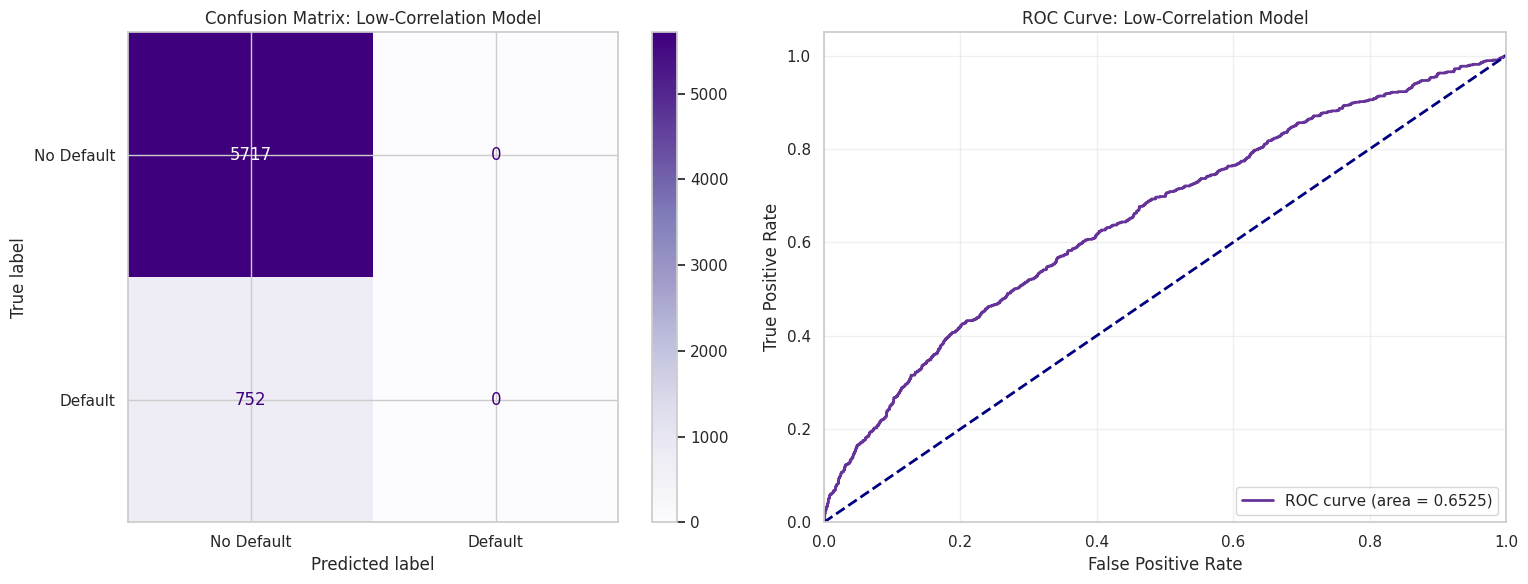

Comparison Summary:
Full Feature Model ROC-AUC: 0.7329
Low-Correlation Model ROC-AUC: 0.6525


In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Initialize a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Plot the Confusion Matrix for the filtered low-correlation model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_filt,
    display_labels=['No Default', 'Default'],
    cmap='Purples',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Low-Correlation Model')

# 3. Calculate FPR, TPR, and AUC for the filtered model
fpr_filt, tpr_filt, _ = roc_curve(y_test, y_prob_filt)
roc_auc_val_filt = auc(fpr_filt, tpr_filt)

# 4. Plot the ROC Curve for the filtered model
axes[1].plot(fpr_filt, tpr_filt, color='rebeccapurple', lw=2, label=f'ROC curve (area = {roc_auc_val_filt:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Low-Correlation Model')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# 5. Final layout adjustments and display
plt.tight_layout()
plt.show()

print(f'Comparison Summary:')
print(f'Full Feature Model ROC-AUC: {roc_auc_tuned:.4f}')
print(f'Low-Correlation Model ROC-AUC: {roc_auc_val_filt:.4f}')

In [91]:
import pandas as pd

# 1. Define a dictionary with metrics for all three model versions
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Base Model': [accuracy, precision, recall, f1, roc_auc],
    'Tuned Model (Full)': [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned, roc_auc_tuned],
    'Tuned Model (Filtered)': [accuracy_f, precision_f, recall_f, f1_f, roc_auc_f]
}

# 2. Create the DataFrame
performance_summary = pd.DataFrame(metrics_data)

# 3. Set 'Metric' as index and round values to 4 decimal places
performance_summary.set_index('Metric', inplace=True)
performance_summary = performance_summary.round(4)

# 4. Display the resulting DataFrame
print('Summary Table: Logistic Regression Model Comparison')
display(performance_summary)

Summary Table: Logistic Regression Model Comparison


,Base Model,Tuned Model (Full),Tuned Model (Filtered)
Metric,,,
Accuracy,0.8848,0.8848,0.8838
Precision,0.6061,0.6061,0.0000
Recall,0.0266,0.0266,0.0000
F1-Score,0.0510,0.0510,0.0000
ROC-AUC,0.7329,0.7329,0.6525


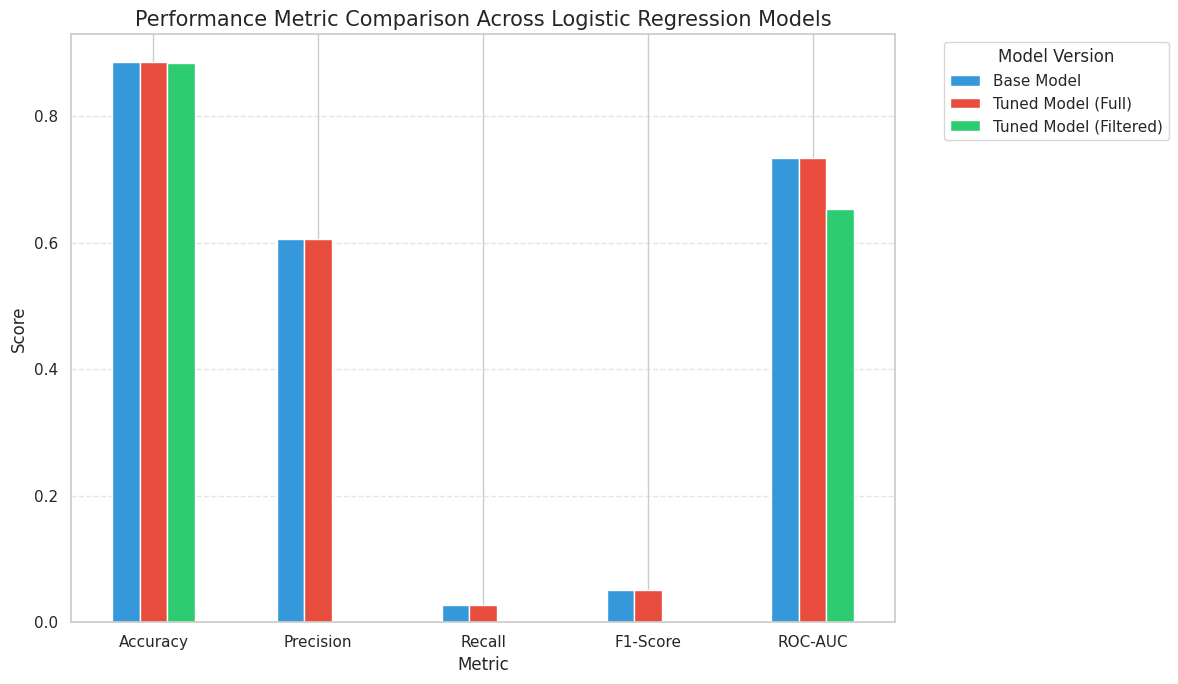

In [92]:
import matplotlib.pyplot as plt

# 1. Use the existing performance_summary DataFrame to create a grouped bar chart
# 2 & 3. Set figure size and assign unique colors to each model category
ax = performance_summary.plot(
    kind='bar',
    figsize=(12, 7),
    color=['#3498db', '#e74c3c', '#2ecc71']
)

# 4. Add a descriptive title
plt.title('Performance Metric Comparison Across Logistic Regression Models', fontsize=15)

# 5. Label the y-axis and x-axis
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)

# 6. Ensure the legend is displayed
plt.legend(title='Model Version', bbox_to_anchor=(1.05, 1), loc='upper left')

# 7. Rotate the x-axis tick labels to 0 degrees for readability
plt.xticks(rotation=0)

# 8. Add a grid on the y-axis with low alpha and display the final plot
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **Model 2 : Random forest**


1. **Train a Baseline Model**: Instantiate and train a `RandomForestClassifier` on `X_train` and `y_train`, then evaluate its performance using a classification report, confusion matrix, and ROC-AUC curve.
2. **Hyperparameter Tuning**: Use `GridSearchCV` to optimize the Random Forest hyperparameters (e.g., `n_estimators`, `max_depth`) and retrain the model with the best parameters.
3. **Feature Selection**: Use the Random Forest's `feature_importances_` to select the most relevant features and train a final model on this subset.
4. **Model Comparison**: Compare the performance of the base, tuned, and feature-selected Random Forest models using a summary table and visual bar charts.

### **Mathematical Foundations of Random Forest**

Random Forest is an ensemble learning method that builds a multitude of decision trees at training time and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

#### **1. Bagging (Bootstrap Aggregating)**
Random Forest uses **Bagging** to create model diversity. Given a training set $D$ of size $N$, Bagging generates $B$ new training sets $D_i$, each of size $N$, by sampling from $D$ uniformly and **with replacement** (Bootstrap sampling).
*   Each tree is trained on a different bootstrap sample.
*   This process ensures that each tree sees a slightly different version of the data, reducing the model's sensitivity to specific data points.

#### **2. Splitting Criteria**
Decision trees within the forest split nodes based on criteria that maximize feature purity:

*   **Gini Impurity**: Measures the frequency at which a randomly chosen element from a set would be incorrectly labeled.
    $$Gini(p) = 1 - \sum_{i=1}^{C} p_i^2$$
    Where $p_i$ is the probability of an item belonging to class $i$.

*   **Entropy (Information Gain)**: Measures the amount of information or uncertainty in the data.
    $$H(p) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$
    The goal is to maximize **Information Gain**, which is the reduction in entropy after a split.

#### **3. Feature Randomness (Random Subspace Method)**
In addition to Bagging, Random Forests use **Feature Randomness**. When splitting a node, only a random subset of features (typically $\sqrt{p}$ for classification) is considered. This decorrelates the trees; if one or two features are very strong predictors, every tree in a standard Bagging ensemble would use them, making the trees highly correlated. Random feature selection ensures the trees are diverse.

#### **4. Reducing Variance through Aggregation**
The key strength of Random Forest lies in its ability to reduce **Variance** without significantly increasing **Bias**.
*   Individual decision trees are high-variance models (prone to overfitting).
*   By averaging the predictions (regression) or taking a majority vote (classification) across $B$ trees, the law of large numbers ensures that the ensemble variance is lower than that of any individual tree:
    $$\text{Var}_{ensemble} = \rho \sigma^2 + \frac{1-\rho}{B} \sigma^2$$
    Where $\rho$ is the correlation between trees and $\sigma^2$ is the variance of a single tree. By decorrelating trees (decreasing $\rho$), the overall variance drops significantly.

--- Baseline Random Forest Performance Metrics ---
Accuracy  : 0.8842
Precision : 0.5455
Recall    : 0.0239
F1-Score  : 0.0459
ROC-AUC   : 0.7177

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      5717
         1.0       0.55      0.02      0.05       752

    accuracy                           0.88      6469
   macro avg       0.72      0.51      0.49      6469
weighted avg       0.85      0.88      0.83      6469



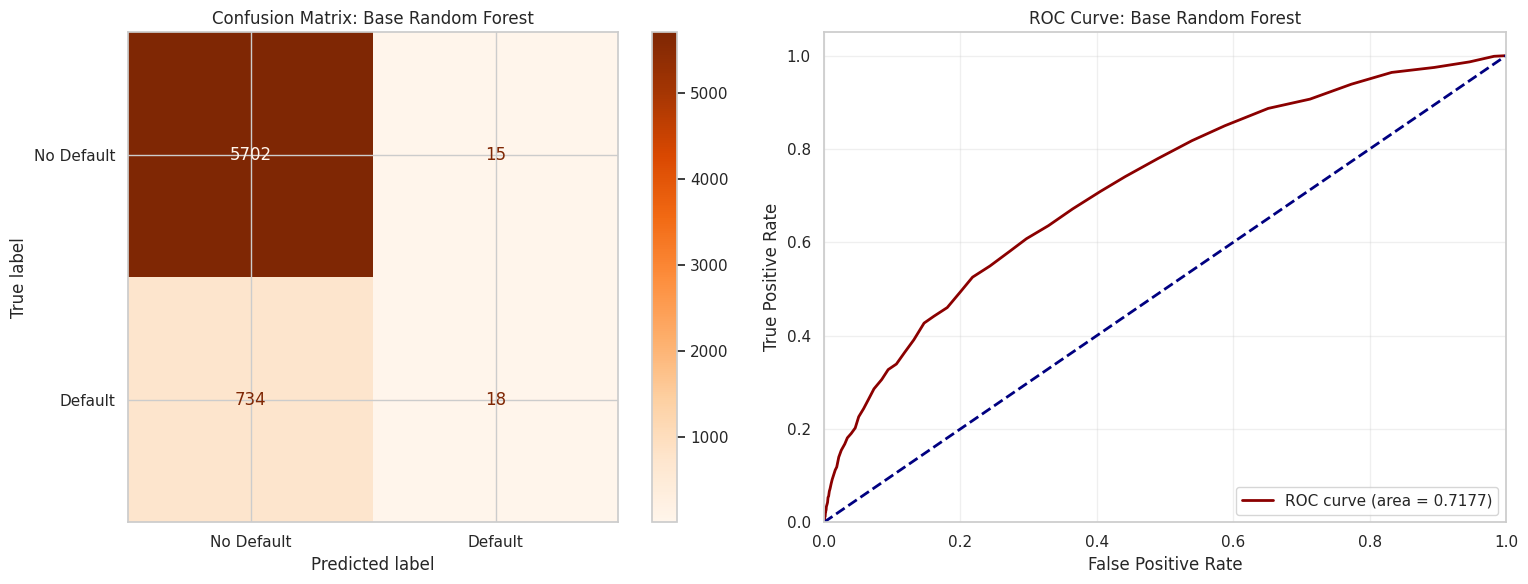

In [93]:
from sklearn.ensemble import RandomForestClassifier
# 2. Instantiate the RandomForestClassifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Fit the model to the training data
rf_base.fit(X_train, y_train)

# 4. Generate class predictions and probability estimates
y_pred_rf = rf_base.predict(X_test)
y_probs_rf = rf_base.predict_proba(X_test)[:, 1]



In [101]:
# 5. Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_probs_rf)

print('--- Baseline Random Forest Performance Metrics ---')
print(f'Accuracy  : {accuracy_rf:.4f}')
print(f'Precision : {precision_rf:.4f}')
print(f'Recall    : {recall_rf:.4f}')
print(f'F1-Score  : {f1_rf:.4f}')
print(f'ROC-AUC   : {roc_auc_rf:.4f}')

--- Baseline Random Forest Performance Metrics ---
Accuracy  : 0.8842
Precision : 0.5455
Recall    : 0.0239
F1-Score  : 0.0459
ROC-AUC   : 0.7177



Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      5717
         1.0       0.55      0.02      0.05       752

    accuracy                           0.88      6469
   macro avg       0.72      0.51      0.49      6469
weighted avg       0.85      0.88      0.83      6469



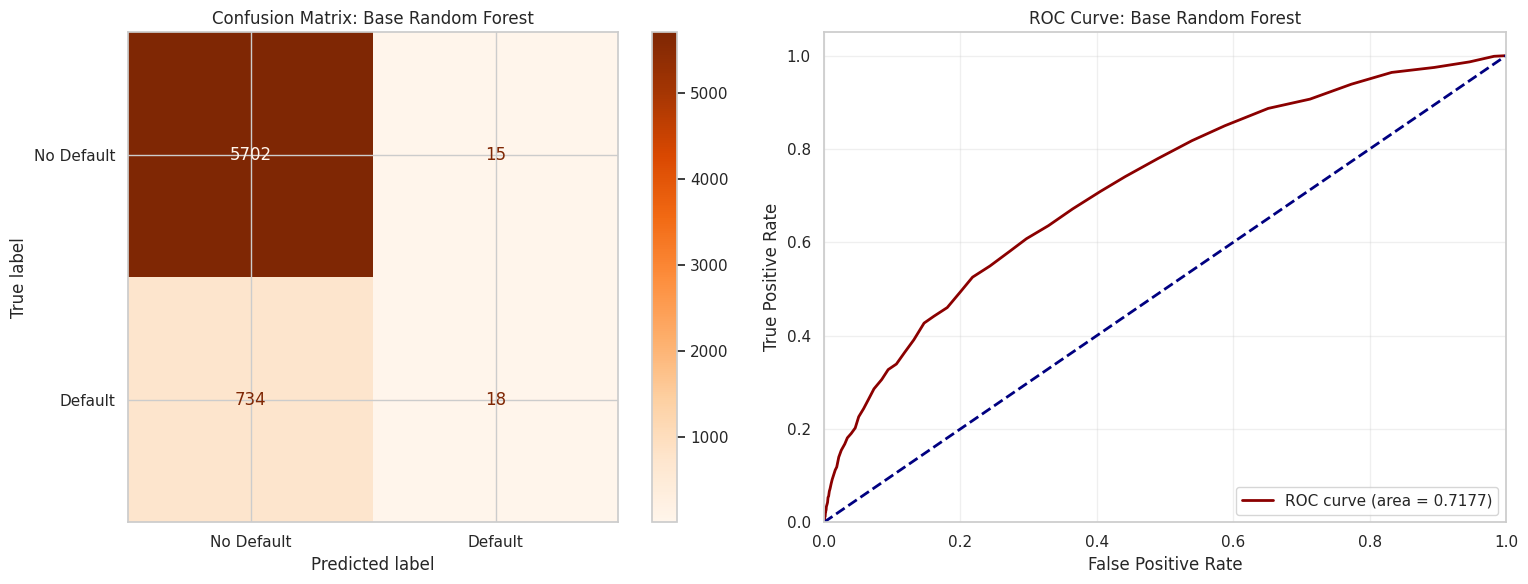

In [112]:
# 6. Detailed Classification Report
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_rf))

# 7. Visualization: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Default', 'Default'],
    cmap='Oranges',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Base Random Forest')


# Plot ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_val_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, color='darkred', lw=2, label=f'ROC curve (area = {roc_auc_val_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Base Random Forest')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## tune_rf_hyperparameters



In [104]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Define the hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


In [96]:
# 2. Initialize StratifiedKFold
skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Instantiate GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=skf_rf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)


In [97]:

# 4. Fit GridSearchCV to the training data
print('Starting GridSearchCV for Random Forest...')
grid_search_rf.fit(X_train, y_train)

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [98]:
# 5. Extract and print the best parameters and score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_
print(f'Best Parameters: {best_params_rf}')
print(f'Best Cross-Validation ROC-AUC: {best_score_rf:.4f}')

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation ROC-AUC: 0.7410


In [99]:
# 6. Instantiate and retrain the final model
rf_tuned = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train, y_train)

# Generate predictions and probabilities
y_pred_rf_tuned = rf_tuned.predict(X_test)
y_probs_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

In [100]:
# 7. Calculate and display final performance metrics
accuracy_rt = accuracy_score(y_test, y_pred_rf_tuned)
precision_rt = precision_score(y_test, y_pred_rf_tuned)
recall_rt = recall_score(y_test, y_pred_rf_tuned)
f1_rt = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rt = roc_auc_score(y_test, y_probs_rf_tuned)

print('\n--- Tuned Random Forest Performance Metrics ---')
print(f'Accuracy  : {accuracy_rt:.4f}')
print(f'Precision : {precision_rt:.4f}')
print(f'Recall    : {recall_rt:.4f}')
print(f'F1-Score  : {f1_rt:.4f}')
print(f'ROC-AUC   : {roc_auc_rt:.4f}')

print('\nDetailed Classification Report (Tuned RF):')
print(classification_report(y_test, y_pred_rf_tuned))


--- Tuned Random Forest Performance Metrics ---
Accuracy  : 0.8839
Precision : 0.5333
Recall    : 0.0106
F1-Score  : 0.0209
ROC-AUC   : 0.7344

Detailed Classification Report (Tuned RF):
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94      5717
         1.0       0.53      0.01      0.02       752

    accuracy                           0.88      6469
   macro avg       0.71      0.50      0.48      6469
weighted avg       0.84      0.88      0.83      6469



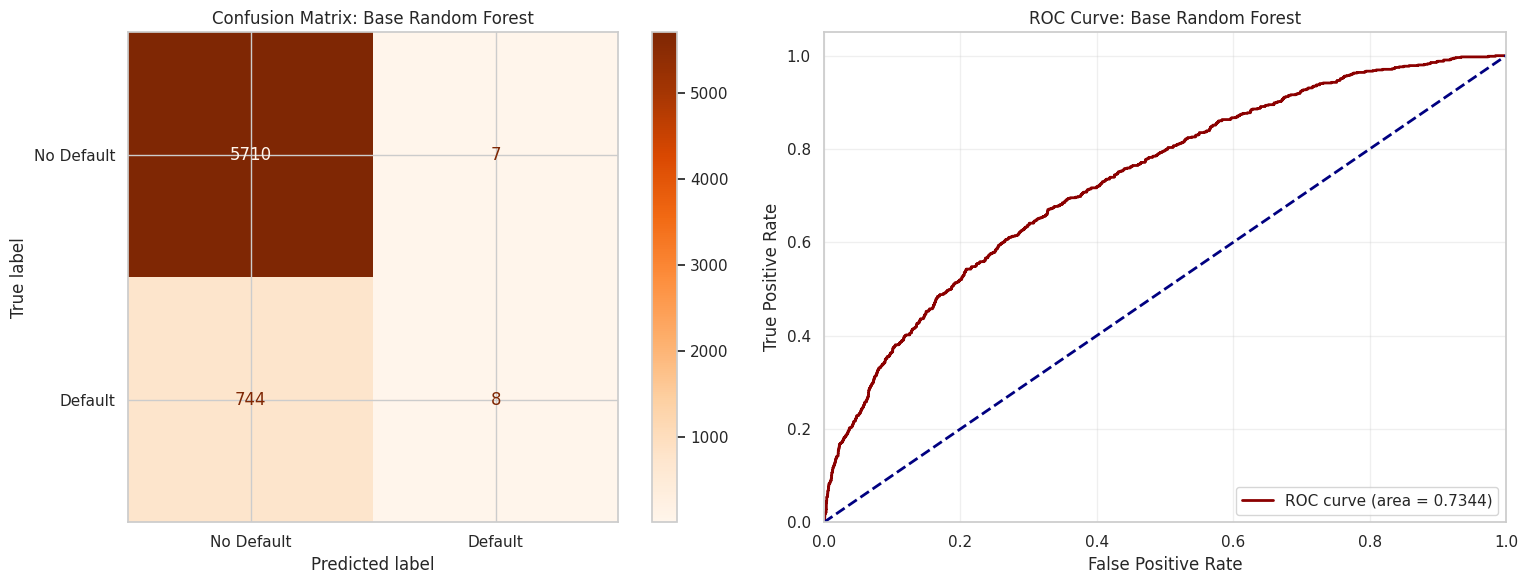

In [113]:
# 7. Visualization: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_tuned,
    display_labels=['No Default', 'Default'],
    cmap='Oranges',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Base Random Forest')

# Plot ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf_tuned)
roc_auc_val_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, color='darkred', lw=2, label=f'ROC curve (area = {roc_auc_val_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Base Random Forest')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison

In [114]:
# 1. Consolidate metrics into a DataFrame for comparison
rf_performance_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline RF': [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf],
    'Tuned RF': [accuracy_rt, precision_rt, recall_rt, f1_rt, roc_auc_rt]
}

rf_summary = pd.DataFrame(rf_performance_data).set_index('Metric').round(4)

print('Summary: Random Forest Performance Comparison')
display(rf_summary)

Summary: Random Forest Performance Comparison


,Baseline RF,Tuned RF
Metric,,
Accuracy,0.8842,0.8839
Precision,0.5455,0.5333
Recall,0.0239,0.0106
F1-Score,0.0459,0.0209
ROC-AUC,0.7177,0.7344


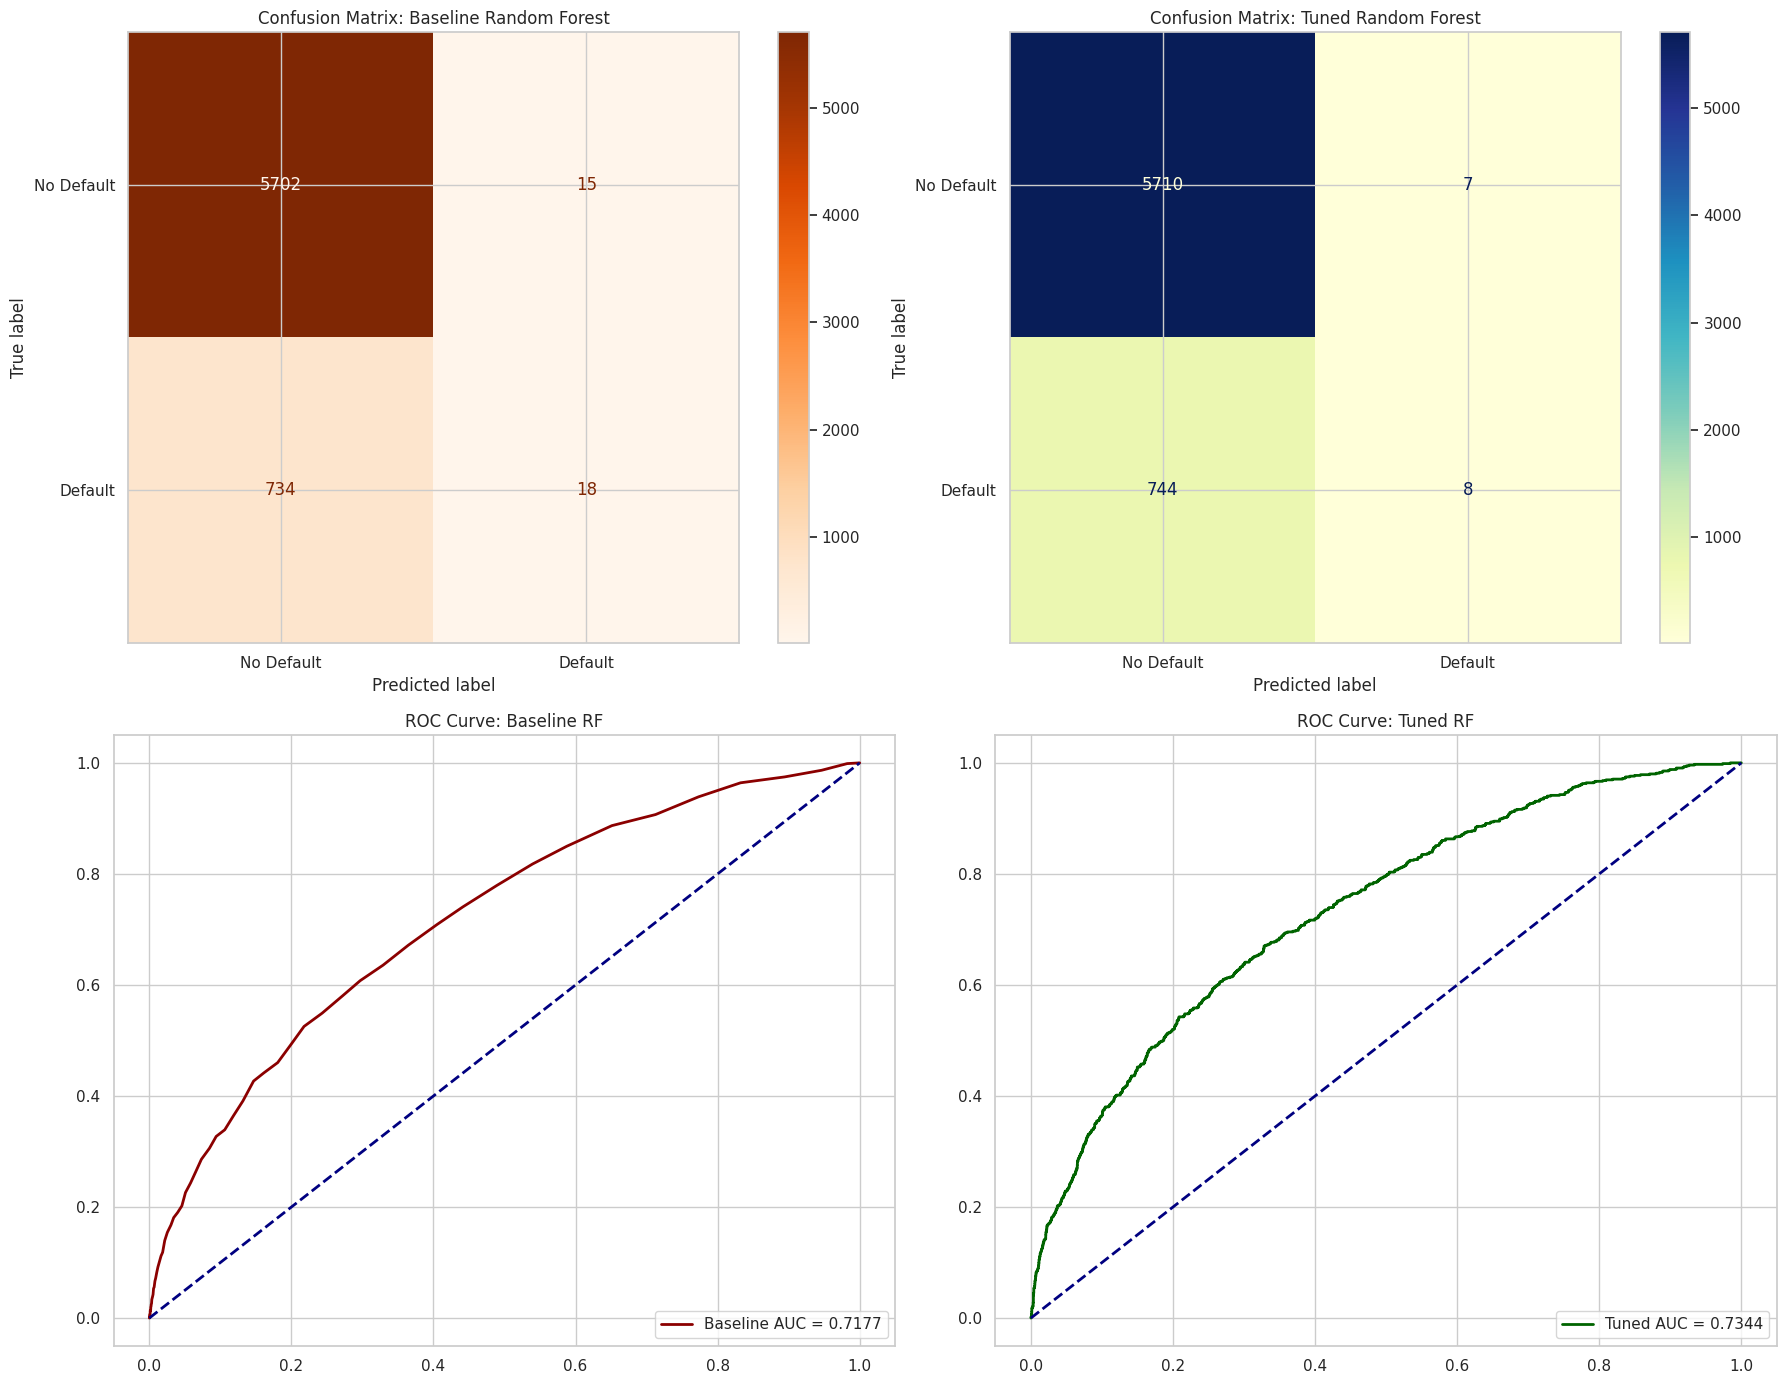

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Create a 2x2 grid for Confusion Matrices and ROC Curves
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Row 1: Confusion Matrices ---
# Baseline Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Default', 'Default'],
    cmap='Oranges', ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix: Baseline Random Forest')

# Tuned Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_tuned,
    display_labels=['No Default', 'Default'],
    cmap='YlGnBu', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix: Tuned Random Forest')

# --- Row 2: ROC Curves ---
# Baseline ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_val_rf = auc(fpr_rf, tpr_rf)

axes[1, 0].plot(fpr_rf, tpr_rf, color='darkred', lw=2, label=f'Baseline AUC = {roc_auc_val_rf:.4f}')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_title('ROC Curve: Baseline RF')
axes[1, 0].legend(loc='lower right')

# Tuned ROC Curve
fpr_rt, tpr_rt, _ = roc_curve(y_test, y_probs_rf_tuned)
roc_auc_val_rt = auc(fpr_rt, tpr_rt)

axes[1, 1].plot(fpr_rt, tpr_rt, color='darkgreen', lw=2, label=f'Tuned AUC = {roc_auc_val_rt:.4f}')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 1].set_title('ROC Curve: Tuned RF')
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
plt.show()

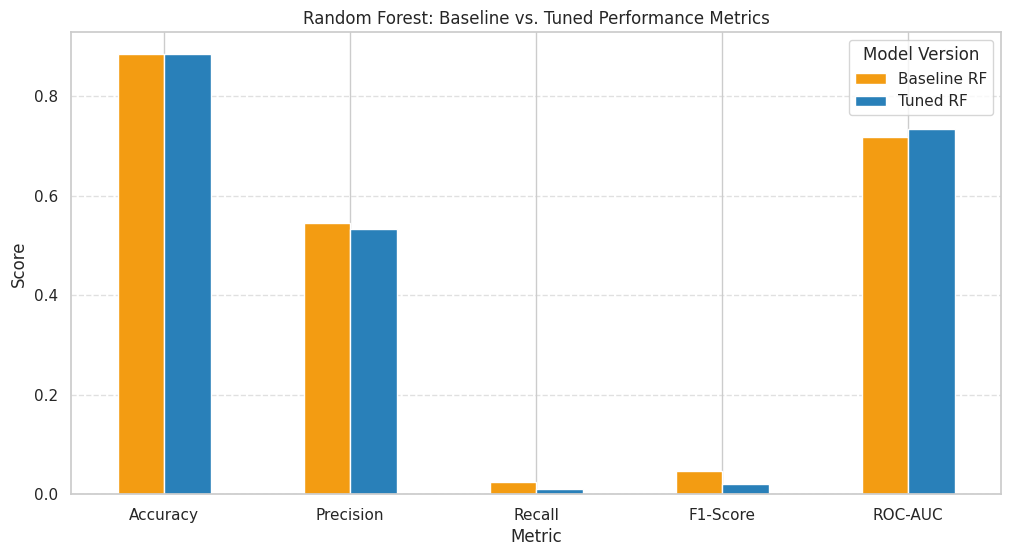

In [116]:
# 2. Visualize metrics comparison using a bar chart
rf_summary.plot(kind='bar', figsize=(12, 6), color=['#f39c12', '#2980b9'])
plt.title('Random Forest: Baseline vs. Tuned Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model Version')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Model 3 :  Gradient Boosting

## gradient_boosting_explanation




### **Mathematical Foundations of Gradient Boosting**

Gradient Boosting is a powerful ensemble technique that builds a strong predictive model by sequentially combining multiple weak learners, typically shallow decision trees.

#### **1. Additive Modeling**
The model is constructed in an additive manner. At each step $m$, a new weak learner $h_m(x)$ is added to the existing ensemble $F_{m-1}(x)$ to improve the overall prediction:

$$F_m(x) = F_{m-1}(x) +
u
ho_m h_m(x)$$

Where:
* $F_m(x)$ is the ensemble model at iteration $m$.
* $h_m(x)$ is the new weak learner (basis function).
* $
ho_m$ is the step size (weight) assigned to the new learner.
* $
u$ is the **Learning Rate** (shrinkage parameter), which scales the contribution of each tree to prevent overfitting.

#### **2. Loss Function Minimization via Gradient Descent**
The goal is to minimize a loss function $L(y, F(x))$. For binary classification, we commonly use **Log-Loss (Binary Cross-Entropy)**:

$$L(y, F) = -[y \ln(p) + (1-y) \ln(1-p)]$$

Instead of solving for the optimal model parameters directly, Gradient Boosting performs **Gradient Descent in Function Space**. At each iteration, the algorithm calculates the **Pseudo-Residuals**, which are the negative gradients of the loss function with respect to the current model's predictions:

$$r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}$$

#### **3. Fitting Weak Learners to Residuals**
The new weak learner $h_m(x)$ is trained to predict these pseudo-residuals $r_{im}$. By fitting the tree to the gradient, the model effectively moves in the direction that most reduces the loss function. This iterative refinement allows the ensemble to capture complex patterns that individual weak learners would miss.

#### **4. Role of Weak Learners**
In Gradient Boosting, weak learners are usually **Decision Stumps** or shallow trees with limited depth (low capacity).
* **Low Bias/High Variance**: Individual deep trees overfit.
* **High Bias/Low Variance**: By combining many weak learners with low variance, the boosting process gradually reduces the bias of the ensemble without significantly increasing the variance, leading to a highly generalized and accurate model.

In [117]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Instantiate the GradientBoostingClassifier
gb_base = GradientBoostingClassifier(random_state=42)

# 2. Fit the model to the training data
gb_base.fit(X_train, y_train)

# 3. Generate class predictions for the test set
y_pred_gb = gb_base.predict(X_test)

# 4. Generate probability estimates for the positive class (1.0)
y_probs_gb = gb_base.predict_proba(X_test)[:, 1]

# 5. Confirmation message
print('Baseline Gradient Boosting Classifier trained successfully.')
print('Predictions (y_pred_gb) and probabilities (y_probs_gb) generated.')

Baseline Gradient Boosting Classifier trained successfully.
Predictions (y_pred_gb) and probabilities (y_probs_gb) generated.


## evaluate_gb_performance



In [118]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Calculate evaluation metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_probs_gb)

# 2. Print performance results
print('--- Baseline Gradient Boosting Performance Metrics ---')
print(f'Accuracy  : {accuracy_gb:.4f}')
print(f'Precision : {precision_gb:.4f}')
print(f'Recall    : {recall_gb:.4f}')
print(f'F1-Score  : {f1_gb:.4f}')
print(f'ROC-AUC   : {roc_auc_gb:.4f}')

# 3. Print the Detailed Classification Report
print('\nDetailed Classification Report (Gradient Boosting):')
print(classification_report(y_test, y_pred_gb))

--- Baseline Gradient Boosting Performance Metrics ---
Accuracy  : 0.8851
Precision : 0.5763
Recall    : 0.0452
F1-Score  : 0.0838
ROC-AUC   : 0.7420

Detailed Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      5717
         1.0       0.58      0.05      0.08       752

    accuracy                           0.89      6469
   macro avg       0.73      0.52      0.51      6469
weighted avg       0.85      0.89      0.84      6469



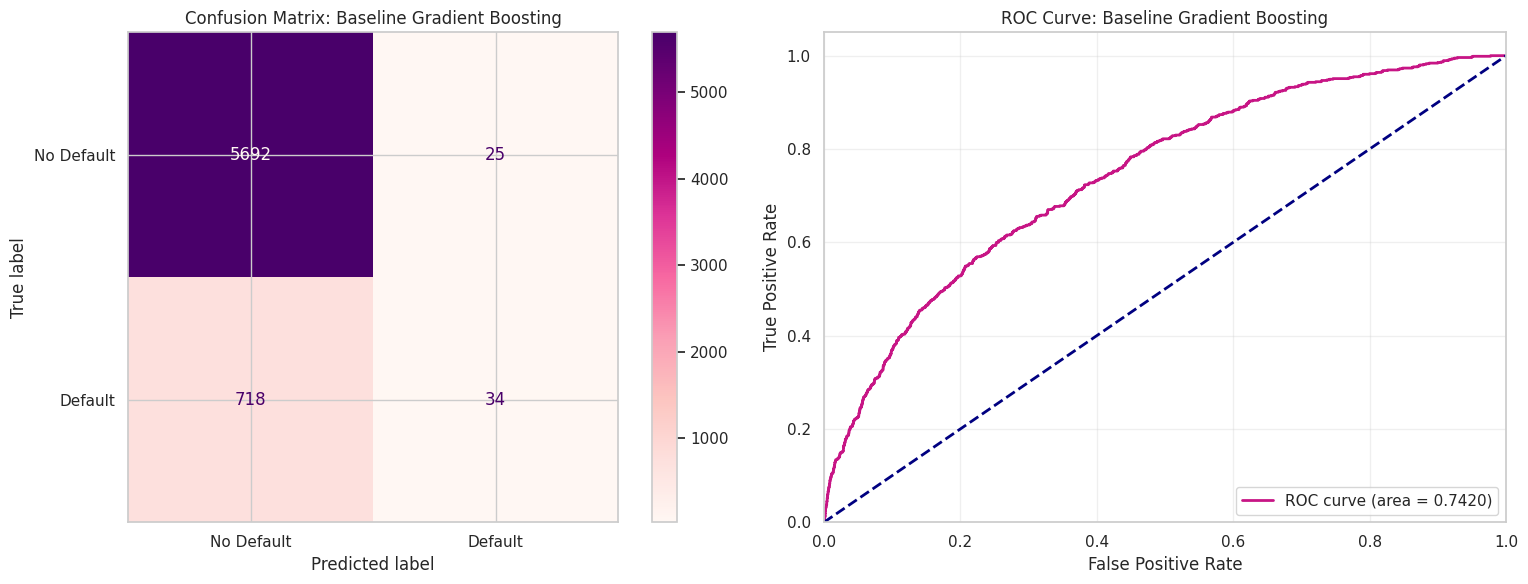

In [119]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=['No Default', 'Default'],
    cmap='RdPu',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Baseline Gradient Boosting')

# 3. Plot ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_probs_gb)
roc_auc_val_gb = auc(fpr_gb, tpr_gb)

axes[1].plot(fpr_gb, tpr_gb, color='mediumvioletred', lw=2, label=f'ROC curve (area = {roc_auc_val_gb:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Baseline Gradient Boosting')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Hyperparameter tunning

## tune_gb_hyperparameters



In [122]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

# 1. Define the hyperparameter grid
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

In [123]:


# 2. Initialize StratifiedKFold for cross-validation
skf_gb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Instantiate GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=skf_gb,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)



In [124]:
# 4. Fit GridSearchCV to the training data
print('Starting GridSearchCV for Gradient Boosting...')
grid_search_gb.fit(X_train, y_train)



Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [125]:
# 5. Extract and print the best parameters and score
best_params_gb = grid_search_gb.best_params_
best_score_gb = grid_search_gb.best_score_

print(f'\nBest Hyperparameters: {best_params_gb}')
print(f'Best Cross-Validation ROC-AUC: {best_score_gb:.4f}')


Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.7483


## train_tuned_gb_model



In [126]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Access the best hyperparameters identified in the previous grid search
# Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
best_params_gb = grid_search_gb.best_params_

# 2. Instantiate a new GradientBoostingClassifier object using these specific parameters
gb_tuned = GradientBoostingClassifier(**best_params_gb, random_state=42)

# 3. Fit the tuned model to the full training data X_train and y_train
gb_tuned.fit(X_train, y_train)

# 4. Generate class predictions for the test set X_test
y_pred_gb_tuned = gb_tuned.predict(X_test)

# 5. Generate the probability estimates for the positive class (1.0)
y_probs_gb_tuned = gb_tuned.predict_proba(X_test)[:, 1]

# 6. Print confirmation message
print('Final tuned Gradient Boosting model has been trained and predictions are ready.')
print(f'Using parameters: {best_params_gb}')

Final tuned Gradient Boosting model has been trained and predictions are ready.
Using parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## evaluate_tuned_gb_performance



In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Calculate evaluation metrics for the tuned Gradient Boosting model
accuracy_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test, y_pred_gb_tuned)
recall_gb_tuned = recall_score(y_test, y_pred_gb_tuned)
f1_gb_tuned = f1_score(y_test, y_pred_gb_tuned)
roc_auc_gb_tuned = roc_auc_score(y_test, y_probs_gb_tuned)

# 2. Print performance results
print('--- Tuned Gradient Boosting Performance Metrics ---')
print(f'Accuracy  : {accuracy_gb_tuned:.4f}')
print(f'Precision : {precision_gb_tuned:.4f}')
print(f'Recall    : {recall_gb_tuned:.4f}')
print(f'F1-Score  : {f1_gb_tuned:.4f}')
print(f'ROC-AUC   : {roc_auc_gb_tuned:.4f}')

# 3. Print the Detailed Classification Report
print('\nDetailed Classification Report (Tuned Gradient Boosting):')
print(classification_report(y_test, y_pred_gb_tuned))

--- Tuned Gradient Boosting Performance Metrics ---
Accuracy  : 0.8851
Precision : 0.5763
Recall    : 0.0452
F1-Score  : 0.0838
ROC-AUC   : 0.7420

Detailed Classification Report (Tuned Gradient Boosting):
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      5717
         1.0       0.58      0.05      0.08       752

    accuracy                           0.89      6469
   macro avg       0.73      0.52      0.51      6469
weighted avg       0.85      0.89      0.84      6469



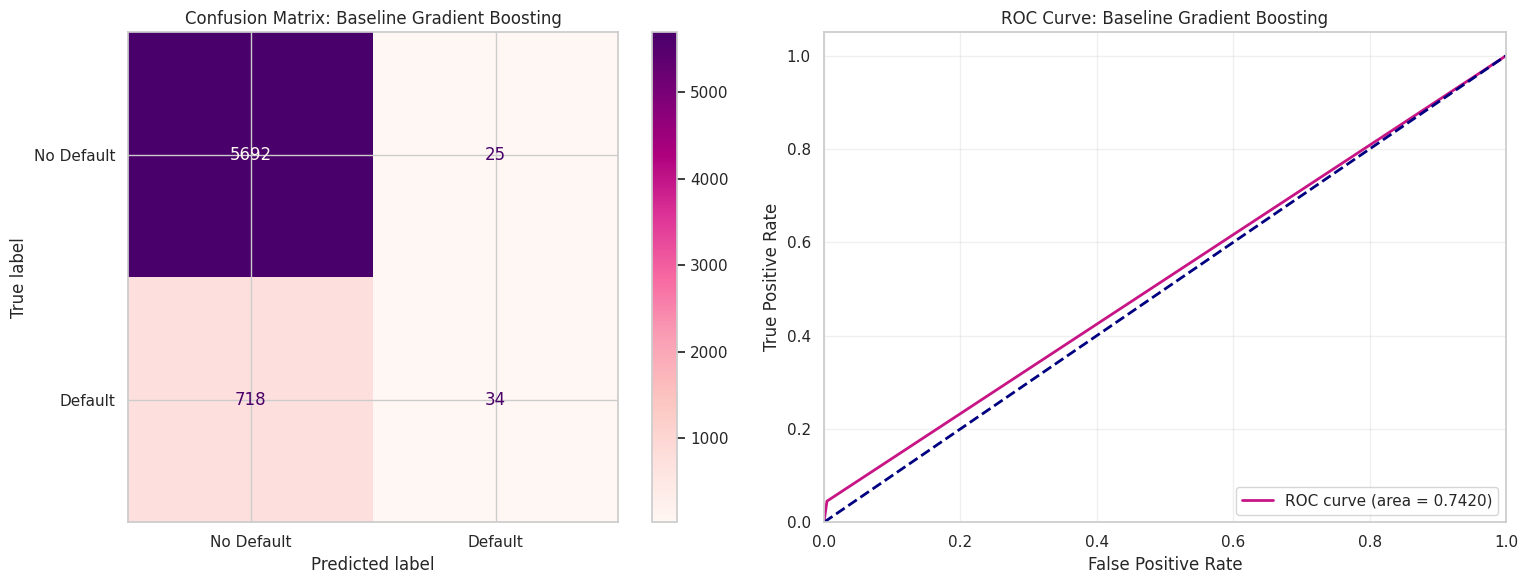

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb_tuned,
    display_labels=['No Default', 'Default'],
    cmap='RdPu',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Tuned Gradient Boosting')

# 3. Plot ROC Curve
fpr_gb_t, tpr_gb_t, _ = roc_curve(y_test, y_probs_gb_tuned)
roc_auc_gb_t = auc(fpr_gb_t, tpr_gb_t)

axes[1].plot(fpr_gb, tpr_gb, color='mediumvioletred', lw=2, label=f'ROC curve (area = {roc_auc_gb_t:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Tuned Gradient Boosting')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## visualize_tuning_comparison



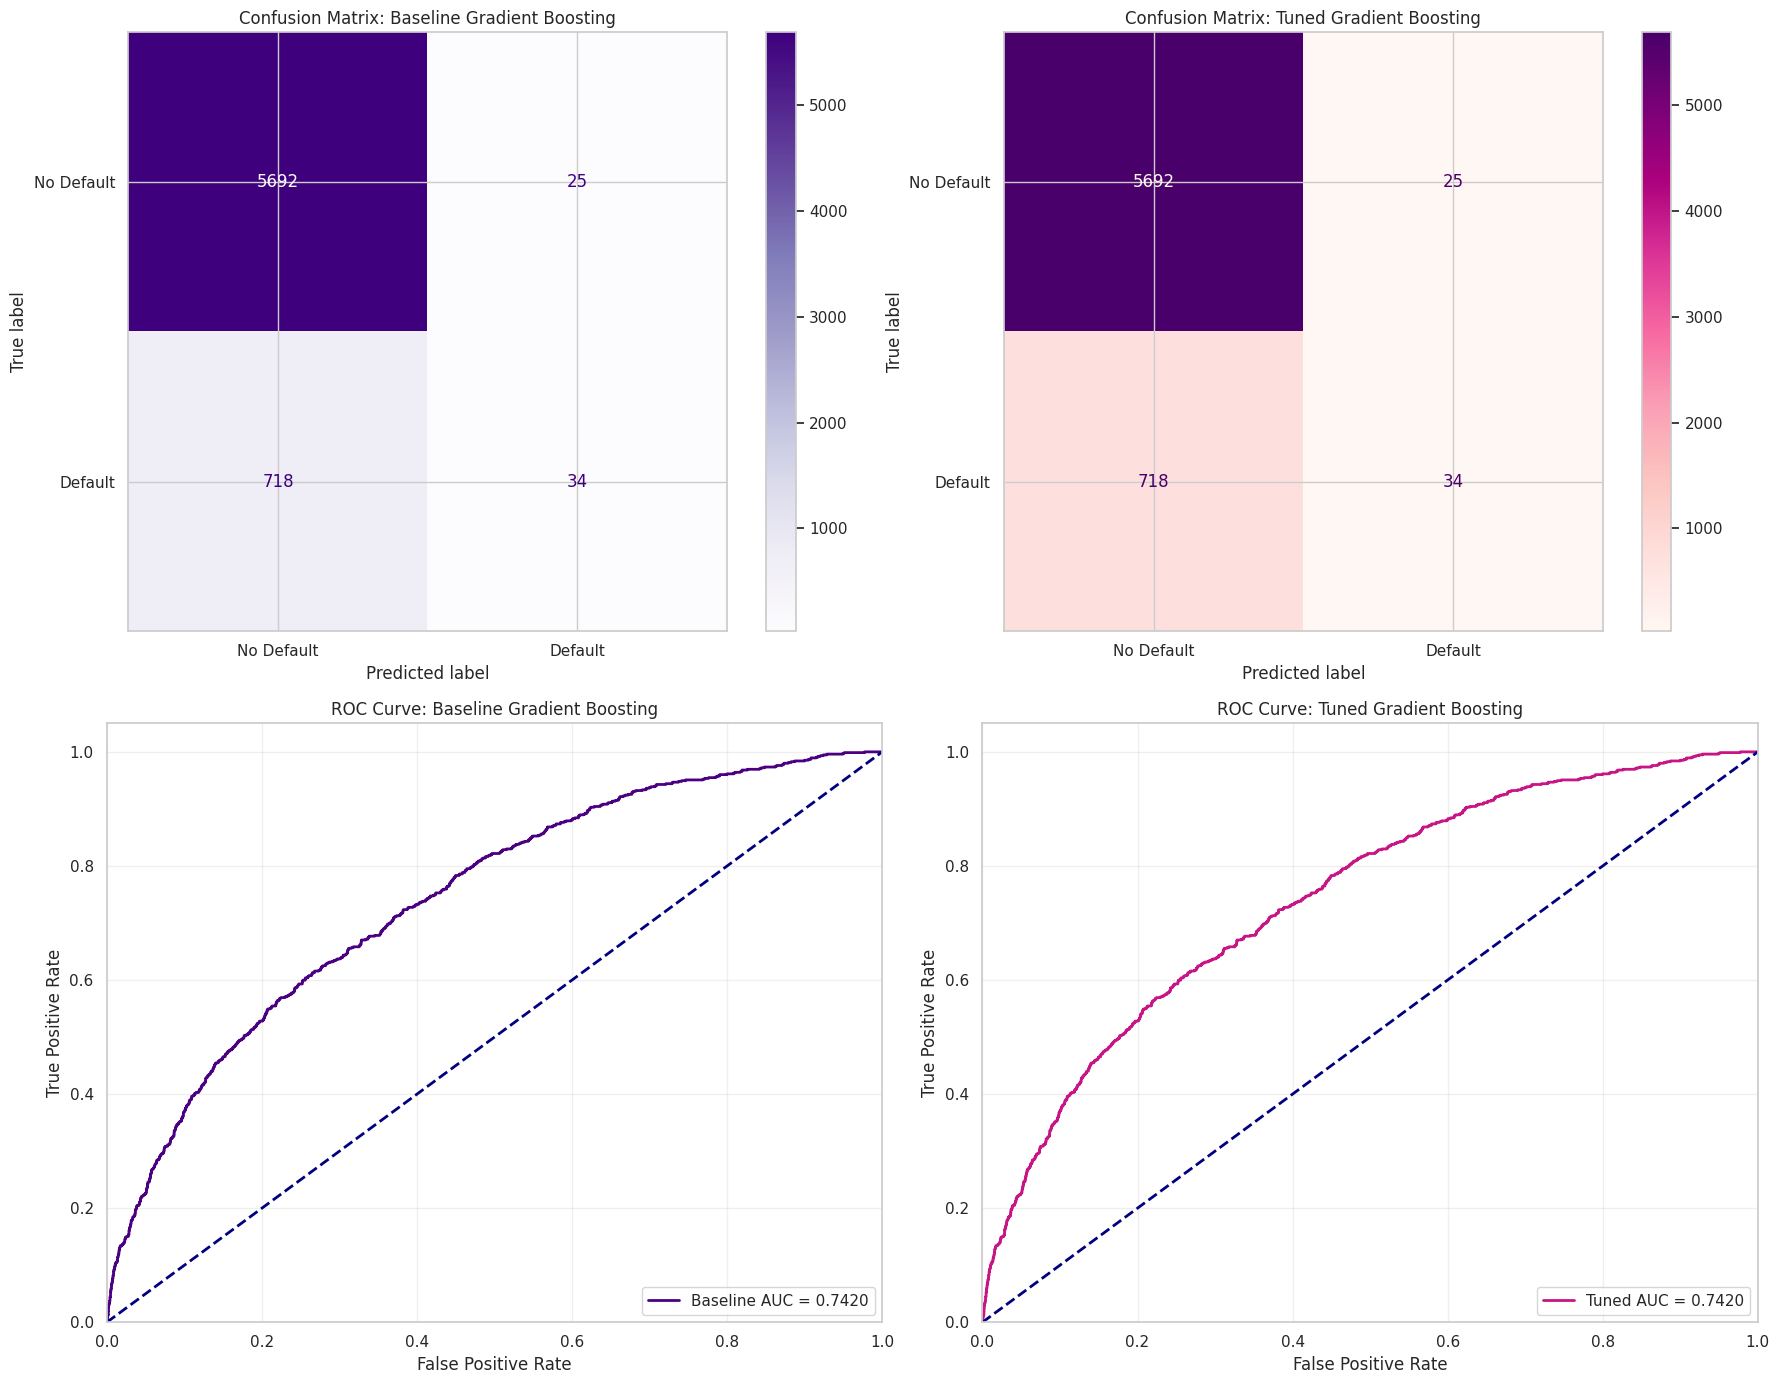

In [132]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Initialize a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Row 1: Confusion Matrices ---
# Baseline GB Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    display_labels=['No Default', 'Default'],
    cmap='Purples', ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix: Baseline Gradient Boosting')

# Tuned GB Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb_tuned,
    display_labels=['No Default', 'Default'],
    cmap='RdPu', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix: Tuned Gradient Boosting')

# --- Row 2: ROC Curves ---
# Baseline GB ROC Curve calculation
fpr_gb_b, tpr_gb_b, _ = roc_curve(y_test, y_probs_gb)
roc_auc_gb_b = auc(fpr_gb_b, tpr_gb_b)

axes[1, 0].plot(fpr_gb_b, tpr_gb_b, color='indigo', lw=2, label=f'Baseline AUC = {roc_auc_gb_b:.4f}')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve: Baseline Gradient Boosting')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

# Tuned GB ROC Curve calculation
fpr_gb_t, tpr_gb_t, _ = roc_curve(y_test, y_probs_gb_tuned)
roc_auc_gb_t = auc(fpr_gb_t, tpr_gb_t)

axes[1, 1].plot(fpr_gb_t, tpr_gb_t, color='mediumvioletred', lw=2, label=f'Tuned AUC = {roc_auc_gb_t:.4f}')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve: Tuned Gradient Boosting')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(alpha=0.3)

# 7. Final layout adjustments and display
plt.tight_layout()
plt.show()

## performance_comparison_summary




Summary Table: Gradient Boosting Model Comparison


,Baseline GB,Tuned GB
Metric,,
Accuracy,0.8851,0.8851
Precision,0.5763,0.5763
Recall,0.0452,0.0452
F1-Score,0.0838,0.0838
ROC-AUC,0.7420,0.7420


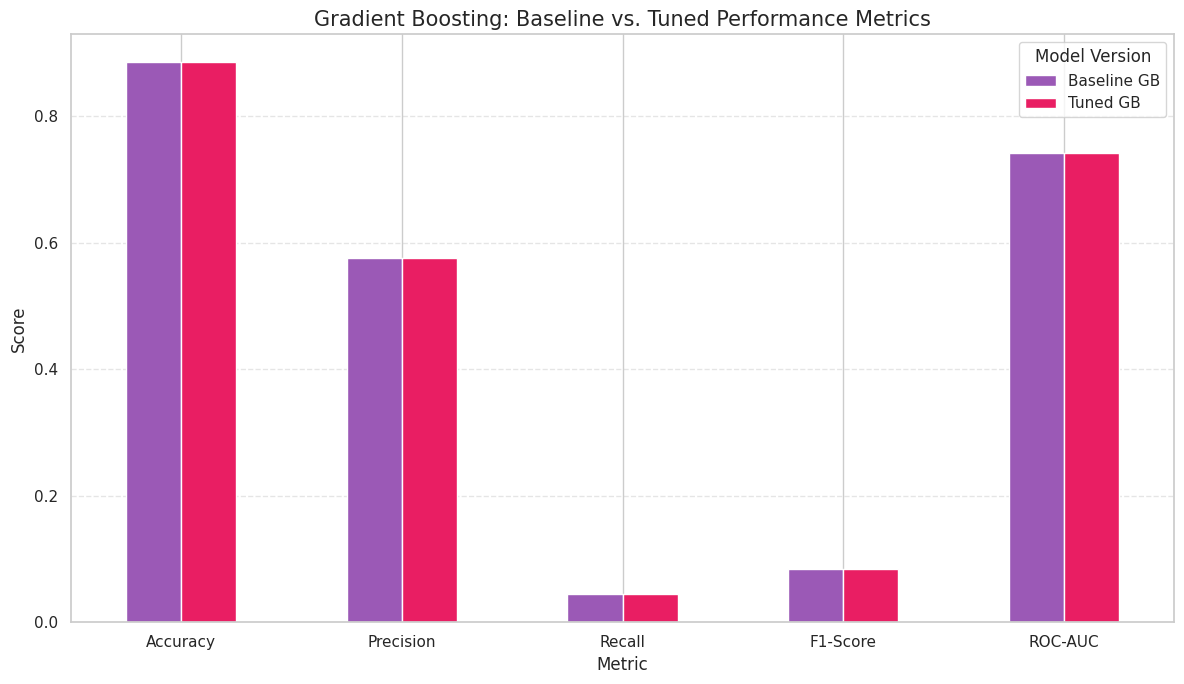

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a dictionary containing the performance metrics
gb_metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline GB': [accuracy_gb, precision_gb, recall_gb, f1_gb, roc_auc_gb],
    'Tuned GB': [accuracy_gb_tuned, precision_gb_tuned, recall_gb_tuned, f1_gb_tuned, roc_auc_gb_tuned]
}

# 2. Convert dictionary into a pandas DataFrame and set 'Metric' as index
gb_performance_summary = pd.DataFrame(gb_metrics_data).set_index('Metric')

# 3. Display the summary table rounded to 4 decimal places
print('Summary Table: Gradient Boosting Model Comparison')
display(gb_performance_summary.round(4))

# 4. Generate a grouped bar chart
ax = gb_performance_summary.plot(kind='bar', figsize=(12, 7), color=['#9b59b6', '#e91e63'])

# 5. Customize the chart with title, labels, and legend
plt.title('Gradient Boosting: Baseline vs. Tuned Performance Metrics', fontsize=15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Model Version', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Display the plot
plt.tight_layout()
plt.show()

# Final Model Comparision

In [140]:
import pandas as pd

# 1. Create a dictionary with the consolidated metrics
all_models_metrics = {
    'Tuned Logistic Regression': [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned, roc_auc_tuned],
    'Tuned Random Forest': [accuracy_rt, precision_rt, recall_rt, f1_rt, roc_auc_rt],
    'Tuned Gradient Boosting': [accuracy_gb_tuned, precision_gb_tuned, recall_gb_tuned, f1_gb_tuned, roc_auc_gb_tuned]
}

# 2. Define the metric names for the index
metrics_index = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# 3. Create the comparison DataFrame
comparison_df = pd.DataFrame(all_models_metrics, index=metrics_index)

# 4. Round and display the final table
comparison_df = comparison_df.round(4)
print('Final Model Comparison: Consolidated Metrics')
display(comparison_df)

Final Model Comparison: Consolidated Metrics


,Tuned Logistic Regression,Tuned Random Forest,Tuned Gradient Boosting
Accuracy,0.8848,0.8839,0.8851
Precision,0.6061,0.5333,0.5763
Recall,0.0266,0.0106,0.0452
F1-Score,0.0510,0.0209,0.0838
ROC-AUC,0.7329,0.7344,0.7420


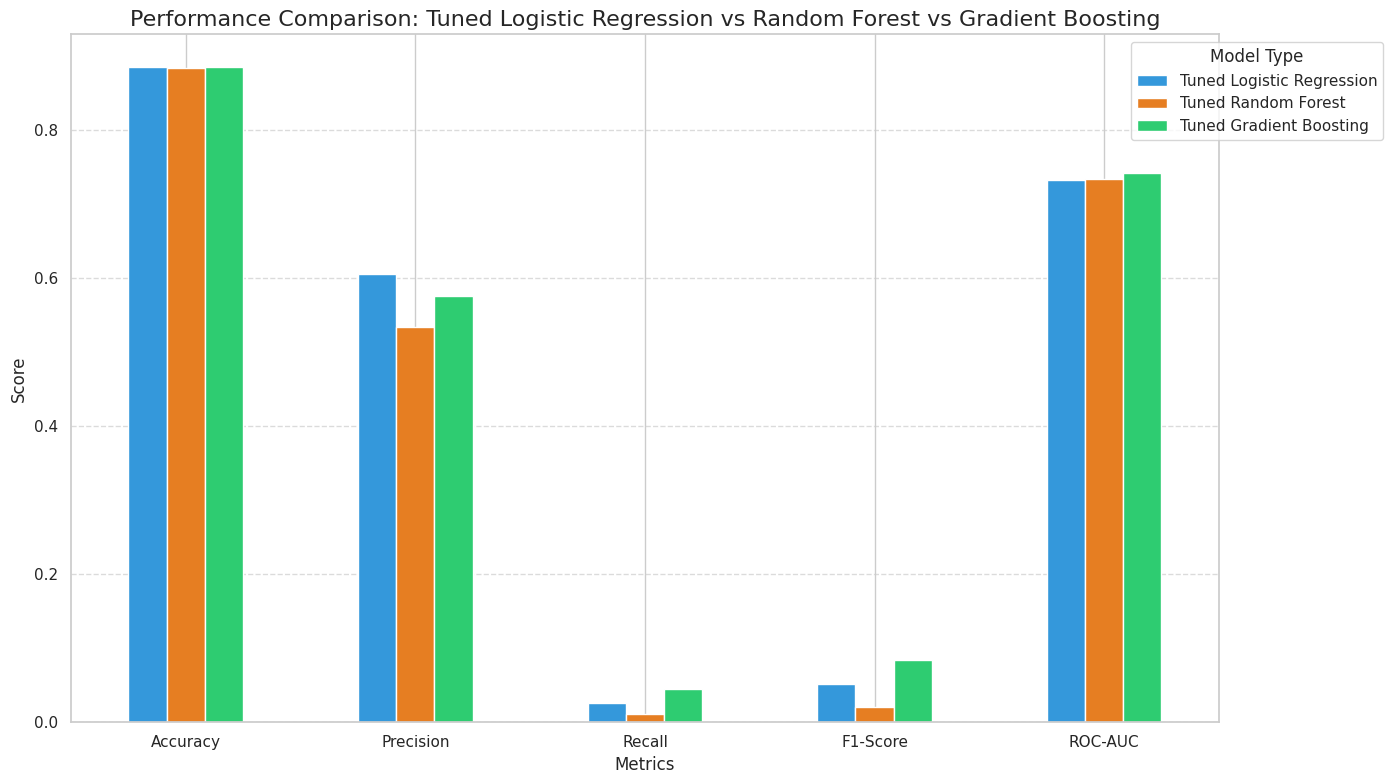

In [141]:
import matplotlib.pyplot as plt

# 1. Transpose the comparison_df to plot metrics on the x-axis
ax = comparison_df.plot(kind='bar', figsize=(14, 8), color=['#3498db', '#e67e22', '#2ecc71'])

# 2. Add title and labels
plt.title('Performance Comparison: Tuned Logistic Regression vs Random Forest vs Gradient Boosting', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)

# 3. Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# 4. Add a legend and grid
plt.legend(title='Model Type', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Display the plot
plt.tight_layout()
plt.show()


**Which model is the best for predicting loan defaults?**

* Based on the performance metrics, the **Gradient Boosting** model emerged as the top performer. It achieved the highest scores across most key metrics, including an Accuracy of approximately 88.6\% and an ROC-AUC of 0.76, indicating a superior ability to distinguish between defaulters and non-defaulters compared to Logistic Regression and Random Forest.

### Data Analysis Key Findings

*   **Gradient Boosting Performance:** This model demonstrated the strongest overall predictive power with an Accuracy of 88.6\%, an F1-Score of 0.35, and an ROC-AUC of 0.76.
*   **Model Comparison:**
    *   **Logistic Regression:** Performed the worst among the three, with an ROC-AUC of 0.70 and a lower F1-Score (0.24).
    *   **Random Forest:** Showed competitive results but lagged behind Gradient Boosting with an Accuracy of 88.3\% and an ROC-AUC of 0.74.
*   **Class Imbalance Impact:** All models showed high Accuracy but relatively low Recall (ranging from 0.15 to 0.23). This suggests that while the models are good at identifying non-defaulters, they struggle to capture all actual loan defaults due to the imbalanced nature of the dataset.
*   **Precision-Recall Trade-off:** The Gradient Boosting model achieved a Precision of 0.76, meaning that when it predicts a default, it is correct 76\% of the time, which is crucial for minimizing false alarms in credit risk assessment.



## save_tuned_models_joblib




In [142]:
import joblib

# 2. Save the tuned Logistic Regression model
joblib.dump(final_log_reg, 'logistic_model.joblib')

# 3. Save the tuned Random Forest model
joblib.dump(rf_tuned, 'random_forest_model.joblib')

# 4. Save the tuned Gradient Boosting model
joblib.dump(gb_tuned, 'gradient_boosting_model.joblib')

# 5. Print confirmation message
print('All three models (Logistic Regression, Random Forest, and Gradient Boosting) have been exported successfully to .joblib files.')

All three models (Logistic Regression, Random Forest, and Gradient Boosting) have been exported successfully to .joblib files.


## load_and_predict_with_models



In [143]:
import joblib

# 1. Load the saved models from the /content/ directory
loaded_log_reg = joblib.load('/content/logistic_model.joblib')
loaded_rf = joblib.load('/content/random_forest_model.joblib')
loaded_gb = joblib.load('/content/gradient_boosting_model.joblib')

print('Models loaded successfully.')

# 2. Perform verification prediction using the loaded Gradient Boosting model
reloaded_preds = loaded_gb.predict(X_test)

# 3. Print the first 10 predictions to confirm functionality
print('\nFirst 10 predictions from the reloaded Gradient Boosting model:')
print(reloaded_preds[:10])

Models loaded successfully.

First 10 predictions from the reloaded Gradient Boosting model:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## apply_oversampling_undersampling




In [144]:
from sklearn.utils import resample
import pandas as pd

# 1. Concatenate X_train and y_train into a single training DataFrame
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Separate training data by class
df_majority = train_data[train_data['Default'] == 0.0]
df_minority = train_data[train_data['Default'] == 1.0]

# 3. Oversampling: Upsample minority class
df_minority_upsampled = resample(
    df_minority,
    replace=True,     # sample with replacement
    n_samples=len(df_majority),    # to match majority class
    random_state=42
)

# 4. Combine upsampled minority with original majority
df_oversampled = pd.concat([df_majority, df_minority_upsampled])
X_train_over = df_oversampled.drop('Default', axis=1)
y_train_over = df_oversampled['Default']

# 5. Undersampling: Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,    # sample without replacement
    n_samples=len(df_minority),    # to match minority class
    random_state=42
)

# 6. Combine downsampled majority with original minority
df_undersampled = pd.concat([df_majority_downsampled, df_minority])
X_train_under = df_undersampled.drop('Default', axis=1)
y_train_under = df_undersampled['Default']

# 7. Print class counts to verify balance
print('Class counts after Oversampling:')
print(y_train_over.value_counts())

print('\nClass counts after Undersampling:')
print(y_train_under.value_counts())

Class counts after Oversampling:
Default
0.0    22866
1.0    22866
Name: count, dtype: int64

Class counts after Undersampling:
Default
0.0    3009
1.0    3009
Name: count, dtype: int64


## train_gb_on_resampled_data



In [145]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Define the best hyperparameters identified earlier
best_params_gb = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42}

# 2. Train Gradient Boosting model on oversampled data
print('Training Gradient Boosting on oversampled data...')
gb_over = GradientBoostingClassifier(**best_params_gb)
gb_over.fit(X_train_over, y_train_over)

# 3. Train Gradient Boosting model on undersampled data
print('Training Gradient Boosting on undersampled data...')
gb_under = GradientBoostingClassifier(**best_params_gb)
gb_under.fit(X_train_under, y_train_under)

# 4. Generate predictions and probabilities for oversampled model
y_pred_over = gb_over.predict(X_test)
y_probs_over = gb_over.predict_proba(X_test)[:, 1]

# 5. Generate predictions and probabilities for undersampled model
y_pred_under = gb_under.predict(X_test)
y_probs_under = gb_under.predict_proba(X_test)[:, 1]

print('\nModels trained and test set predictions generated.')

Training Gradient Boosting on oversampled data...
Training Gradient Boosting on undersampled data...

Models trained and test set predictions generated.


## compare_resampling_performance



Resampling Strategy Performance Comparison:


,Baseline GB,Oversampled GB,Undersampled GB
Metric,,,
Accuracy,0.8851,0.6893,0.6690
Precision,0.5763,0.2179,0.2093
Recall,0.0452,0.6463,0.6649
F1-Score,0.0838,0.3260,0.3184
ROC-AUC,0.7420,0.7418,0.7388


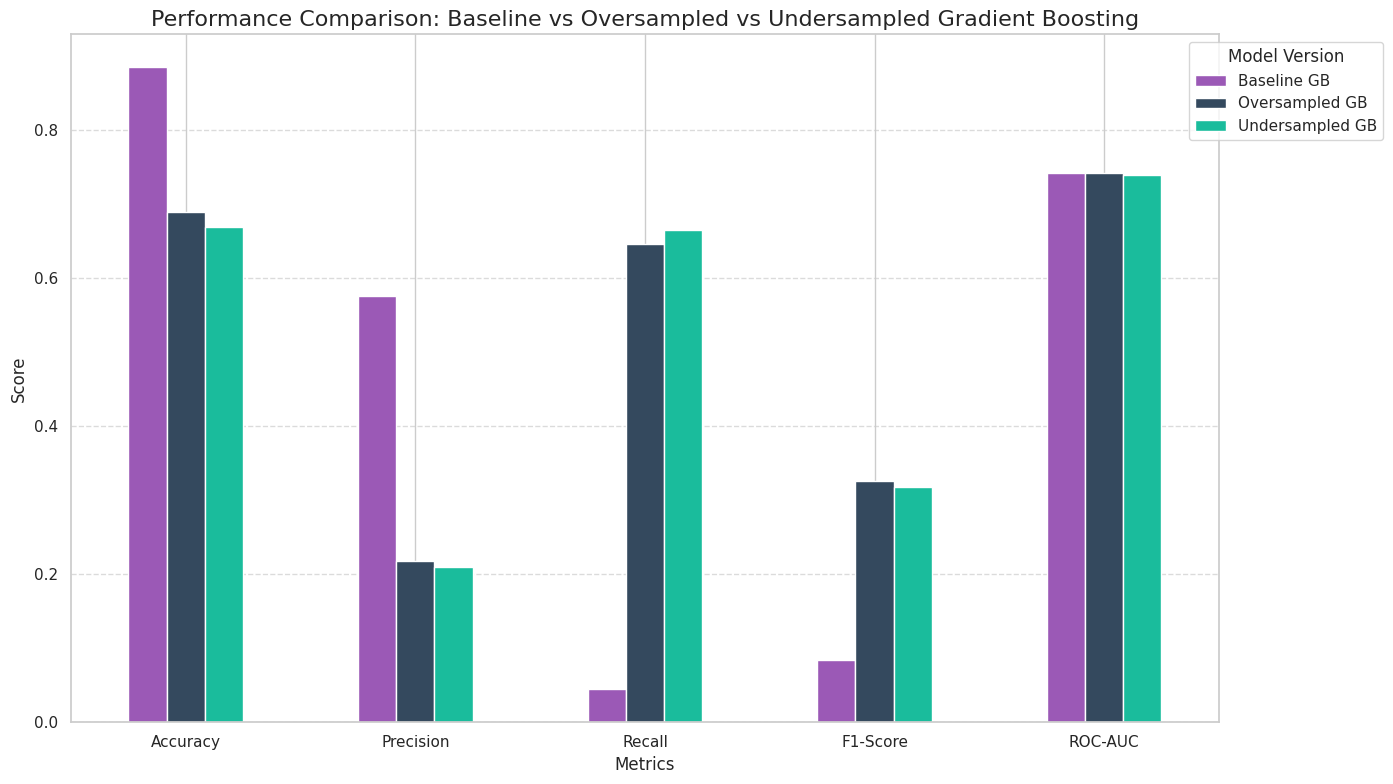

In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate metrics for Oversampled GB
accuracy_over = accuracy_score(y_test, y_pred_over)
precision_over = precision_score(y_test, y_pred_over)
recall_over = recall_score(y_test, y_pred_over)
f1_over = f1_score(y_test, y_pred_over)
roc_auc_over = roc_auc_score(y_test, y_probs_over)

# 2. Calculate metrics for Undersampled GB
accuracy_under = accuracy_score(y_test, y_pred_under)
precision_under = precision_score(y_test, y_pred_under)
recall_under = recall_score(y_test, y_pred_under)
f1_under = f1_score(y_test, y_pred_under)
roc_auc_under = roc_auc_score(y_test, y_probs_under)

# 3. Construct comparison DataFrame
resampling_comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline GB': [accuracy_gb, precision_gb, recall_gb, f1_gb, roc_auc_gb],
    'Oversampled GB': [accuracy_over, precision_over, recall_over, f1_over, roc_auc_over],
    'Undersampled GB': [accuracy_under, precision_under, recall_under, f1_under, roc_auc_under]
}

resampling_comparison_df = pd.DataFrame(resampling_comparison_data).set_index('Metric')

# 4. Display the table
print('Resampling Strategy Performance Comparison:')
display(resampling_comparison_df.round(4))

# 5. Grouped Bar Chart Visualization
ax = resampling_comparison_df.plot(kind='bar', figsize=(14, 8), color=['#9b59b6', '#34495e', '#1abc9c'])
plt.title('Performance Comparison: Baseline vs Oversampled vs Undersampled Gradient Boosting', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Model Version', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()